In [3]:
from astropy.io import fits

gal_frame = fits.open('/home/benjamin/Documents/pypeit18/mage0075.fits')
gal_frame2 = fits.open('/home/benjamin/Documents/pypeit18/mage0078.fits')

In [4]:
gal_frame2[0].header

SIMPLE  =                    T                                                  
BITPIX  =                   16                                                  
NAXIS   =                    2                                                  
NAXIS1  =                 2176                                                  
NAXIS2  =                 1152                                                  
BSCALE  =           1.00000000         / real=bzero+bscale*value                
BZERO   =       32768.00000000                                                  
BUNIT   = 'DU/PIXEL'                                                            
ORIGIN  = 'LCO/OCIW'                                                            
OBSERVER= 'MagInst'                    / observer name                          
TELESCOP= 'Baade_Mag_1'                / telescope                              
SITENAME= 'LCO'                                                                 
SITEALT =                 24

# Plots

# Check if atmospheric effects affect relevant lines

In [31]:
from astropy.io import fits
import matplotlib.pyplot as plt

#Absorption is between 6800 to 7000, and the second is
#at 7600 to 7800

spec = fits.open('/home/benjamin/Documents/pypeit19b/redux_J2337/red/magellan_mage_A/J2337_red.fits')

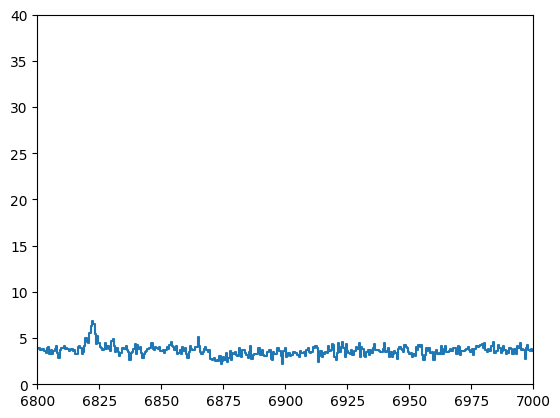

In [38]:
plt.step(spec[1].data['wave'], spec[1].data['flux'], where='mid')
plt.xlim(6800, 7000)
plt.ylim(0, 40)
plt.axvline((1 + 0.07203)*7065, ls='--')

# Test jacknife on coadding J1146, check H$\alpha$

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt

jknf1 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J1146/red/magellan_mage_A/J1146_red_1_tellcorr.fits')
jknf2 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J1146/red/magellan_mage_A/J1146_red_2_tellcorr.fits')
jknf3 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J1146/red/magellan_mage_A/J1146_red_3_tellcorr.fits')

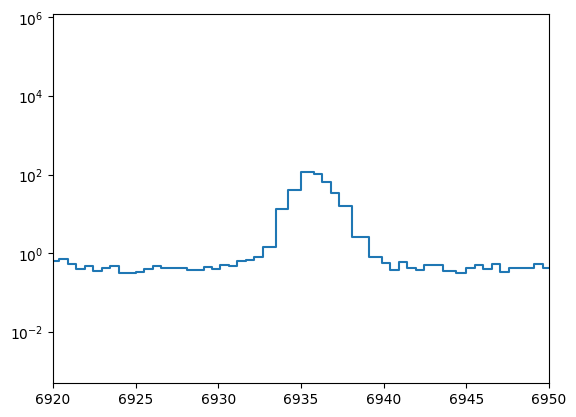

In [5]:
plt.step(jknf1[1].data['wave'], jknf1[1].data['flux'], where='mid', label='Jacknife 1')
#plt.step(jknf2[1].data['wave'], jknf2[1].data['flux'], where='mid', label='Jacknife 2')
#plt.step(jknf3[1].data['wave'], jknf3[1].data['flux'], where='mid', label='Jacknife 3')

plt.xlim(6920, 6950)
#plt.ylim(0.1, 5e2)
#plt.ylim(-10, 120)
plt.yscale('log')

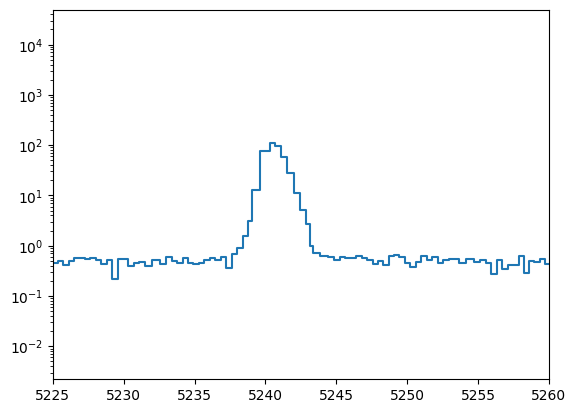

In [8]:
#plt.step(jknf1[1].data['wave'], jknf1[1].data['flux'], where='mid', label='Jacknife 1')
plt.step(jknf2[1].data['wave'], jknf2[1].data['flux'], where='mid', label='Jacknife 2')
#plt.step(jknf3[1].data['wave'], jknf3[1].data['flux'], where='mid', label='Jacknife 3')

plt.xlim(5225, 5260)
#plt.ylim(0.1, 5e2)
#plt.ylim(-10, 350)
plt.yscale('log')

In [11]:
print('Jacknife is the only good Halpha')
print('But [OIII]4959 is bad. Testing with individual frames...')
print('Ther is no way to get it right.')
print('Last option would be to do a triple merge with a jacknife who has good Ha and other with [OIII] with the blue spec')

Jacknife is the only good Halpha
But [OIII]4959 is bad. Testing with individual frames...
Ther is no way to get it right.
Last option would be to do a triple merge with a jacknife who has good Ha and other with [OIII] with the blue spec


# Test reducing a galaxy of 2018 with pypeit v1.15

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt

red_15 = fits.open('/home/benjamin/Documents/pypeit18/test_pp15_J0021/red/magellan_mage_A/J0021_red_tellcorr.fits')
blue_15 = fits.open('/home/benjamin/Documents/pypeit18/test_pp15_J0021/blue/magellan_mage_A/J0021_blue_tellcorr.fits')

red = fits.open('/home/benjamin/Documents/pypeit18/redux_J0021/red/magellan_mage_A/J0021_red_tellcorr.fits')
blue = fits.open('/home/benjamin/Documents/pypeit18/redux_J0021/blue/magellan_mage_A/J0021_blue_tellcorr.fits')

In [6]:
red[1].data['wave']

array([ 4063.0747666 ,  4063.41350974,  4063.75222548, ...,
       11055.99050172, 11056.67674069, 11057.3636153 ])

(0.0, 1000.0)

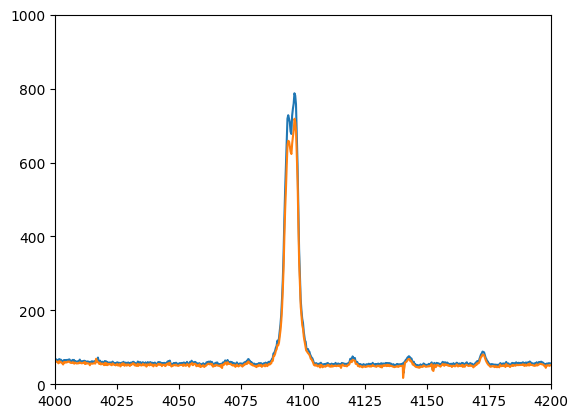

In [33]:
plt.plot(blue[1].data['wave'], blue[1].data['flux'])
plt.plot(blue_15[1].data['wave'], blue_15[1].data['flux'])

plt.axvline(4976, color='k', ls='--')
plt.xlim(4000, 4200)
plt.ylim(0, 1000)

---

# Temden & Chemical abundances

In [14]:
import pandas as pd
import uncertainties.unumpy as upy

temden_measured = pd.read_csv('/home/benjamin/Documents/analogs/results/metals/temden_measured_final.csv')
abundance_measured = pd.read_csv('/home/benjamin/Documents/analogs/results/metals/abundance_measured_final.csv')

In [18]:
cols = ['galname', 'log_OH', 'log_OH_16', 'log_OH_84',
                   'log_NH', 'log_NH_16', 'log_NH_84',
                   'log_NO', 'log_NO_16', 'log_NO_84',
                   'He/H', 'He/H_16', 'He/H_84']

abundance_measured.to_latex(columns=cols, float_format='%.3f', index=None)

'\\begin{tabular}{llrrrrrrrrrrrr}\n\\toprule\n & galname & He/H & He/H_16 & He/H_84 & log_OH & log_OH_16 & log_OH_84 & log_NH & log_NH_16 & log_NH_84 & log_NO & log_NO_16 & log_NO_84 \\\\\n\\midrule\n0 & J0021 & 0.087 & 0.087 & 0.087 & 8.237 & 8.224 & 8.251 & 7.228 & 7.217 & 7.240 & -1.014 & -1.025 & -1.003 \\\\\n1 & J0023 & 0.096 & 0.096 & 0.096 & 8.081 & 8.072 & 8.090 & 6.748 & 6.736 & 6.759 & -1.329 & -1.341 & -1.318 \\\\\n2 & J0136 & NaN & NaN & NaN & 8.154 & 8.132 & 8.179 & 6.430 & 6.404 & 6.457 & -1.696 & -1.737 & -1.658 \\\\\n3 & J0240 & 0.083 & 0.083 & 0.083 & 7.978 & 7.971 & 7.986 & 7.020 & 6.991 & 7.048 & -0.900 & -0.927 & -0.874 \\\\\n4 & J0252 & NaN & NaN & NaN & 8.011 & 7.990 & 8.034 & 6.354 & 6.324 & 6.386 & -1.601 & -1.642 & -1.562 \\\\\n5 & J0305 & NaN & NaN & NaN & 8.317 & 8.274 & 8.363 & 6.820 & 6.800 & 6.841 & -1.472 & -1.508 & -1.436 \\\\\n6 & J0950 & 0.091 & 0.091 & 0.091 & 8.621 & 8.605 & 8.637 & 6.759 & 6.751 & 6.767 & -1.860 & -1.868 & -1.851 \\\\\n7 & J1146 & 0

In [12]:
temden_measured.to_latex(float_format='%.3f', index=None)

'\\begin{tabular}{llrrrrrrrrrrrrrrr}\n\\toprule\n & galname & tOIII & tOIII_16 & tOIII_84 & tOII & tOII_16 & tOII_84 & ne & ne_16 & ne_84 & tNII & tNII_16 & tNII_84 & tSIII & tSIII_16 & tSIII_84 \\\\\n\\midrule\n0 & J0021 & 1.076 & 1.065 & 1.087 & 1.072 & 1.055 & 1.089 & 122.997 & 114.714 & 131.248 & 1.658 & 1.585 & 1.731 & 0.998 & 0.979 & 1.018 \\\\\n1 & J0023 & 1.247 & 1.238 & 1.257 & 1.379 & 1.353 & 1.406 & 69.427 & 59.788 & 79.414 & NaN & NaN & NaN & 1.306 & 1.276 & 1.336 \\\\\n2 & J0136 & 1.349 & 1.330 & 1.367 & 1.137 & 1.074 & 1.201 & 70.276 & 37.628 & 104.925 & NaN & NaN & NaN & 1.287 & 1.220 & 1.356 \\\\\n3 & J0240 & 1.440 & 1.431 & 1.448 & 1.595 & 1.510 & 1.682 & 437.986 & 383.509 & 494.862 & NaN & NaN & NaN & 1.471 & 1.402 & 1.543 \\\\\n4 & J0252 & 1.448 & 1.425 & 1.470 & 1.245 & 1.169 & 1.325 & 112.786 & 78.802 & 149.276 & NaN & NaN & NaN & 1.239 & 1.170 & 1.309 \\\\\n5 & J0305 & 1.215 & 1.184 & 1.246 & 0.904 & 0.867 & 0.945 & 114.009 & 82.182 & 147.481 & NaN & NaN & NaN & 1

In [15]:
temdict = {'ID': temden_measured['galname'].to_numpy(),
           'ne': upy.uarray(temden_measured['ne'].to_numpy(), temden_measured['ne_err'].to_numpy()),
           'T[OIII]': upy.uarray(temden_measured['tOIII'].to_numpy(), temden_measured['tOIII_err'].to_numpy()),
           'T[OII]': upy.uarray(temden_measured['tOII'].to_numpy(), temden_measured['tOII_err'].to_numpy()),
           'T[SIII]': upy.uarray(temden_measured['tSIII'].to_numpy(), temden_measured['tSIII_err'].to_numpy()),
           'T[NII]': upy.uarray(temden_measured['tNII'].to_numpy(), temden_measured['tNII_err'].to_numpy())
}
temdict_pd = pd.DataFrame(data=temdict, index=None)

/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/numpy/lib/function_base.py:2412: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)


In [19]:
abundict = {'ID': abundance_measured['galname'].to_numpy(),
            'He/H': 12 + upy.log10(upy.uarray(abundance_measured['He/H'].to_numpy(), abundance_measured['He/H_err'].to_numpy())),
            'log_OH': upy.uarray(abundance_measured['log_OH'].to_numpy(), abundance_measured['log_OH_err'].to_numpy()),
            'log_NH': upy.uarray(abundance_measured['log_NH'].to_numpy(), abundance_measured['log_NH_err'].to_numpy()),
            'log_SH': upy.uarray(abundance_measured['log_SH'].to_numpy(), abundance_measured['log_SH_err'].to_numpy()),
            'log_NeH': upy.uarray(abundance_measured['log_NeH'].to_numpy(), abundance_measured['log_NeH_err'].to_numpy()),
            'log_ArH': upy.uarray(abundance_measured['log_ArH'].to_numpy(), abundance_measured['log_ArH_err'].to_numpy()),
            'log_FeH': upy.uarray(abundance_measured['log_FeH'].to_numpy(), abundance_measured['log_FeH_err'].to_numpy()),
            'log_NO': upy.uarray(abundance_measured['log_NO'].to_numpy(), abundance_measured['log_NO_err'].to_numpy()),
            'log_q': upy.uarray(abundance_measured['log_q'].to_numpy(), abundance_measured['log_q_err'].to_numpy())
}
abundict_pd = pd.DataFrame(data=abundict, index=None)

/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/numpy/lib/function_base.py:2412: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)


In [17]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
temdict_pd['ne'][3]#.to_latex(float_format='%.3f', index=None)

435.3932825753826+/-165.3854498597937

In [21]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
abundict_pd
abundict_pd.to_latex(float_format='%.3f', index=None, columns=['He/H'])

'\\begin{tabular}{ll}\n\\toprule\n & He/H \\\\\n\\midrule\n0 & 10.941+/-0.013 \\\\\n1 & 10.952+/-0.019 \\\\\n2 & nan+/-nan \\\\\n3 & 10.92+/-0.05 \\\\\n4 & nan+/-nan \\\\\n5 & nan+/-nan \\\\\n6 & 10.99+/-0.04 \\\\\n7 & 10.918+/-0.030 \\\\\n8 & 10.935+/-0.021 \\\\\n9 & 11.023+/-0.025 \\\\\n10 & 10.828+/-0.015 \\\\\n11 & nan+/-nan \\\\\n12 & 10.97+/-0.04 \\\\\n13 & 10.86+/-0.05 \\\\\n14 & nan+/-nan \\\\\n15 & 10.995+/-0.017 \\\\\n16 & 10.936+/-0.017 \\\\\n17 & 10.97+/-0.05 \\\\\n\\bottomrule\n\\end{tabular}\n'

# Balmer decrements

In [6]:
import pandas as pd
import numpy as np
import uncertainties.unumpy as upy

bal_dec = pd.read_csv('/home/benjamin/Documents/analogs/results/bal_decrements.csv')

In [7]:
new_bal_dec = {'galname': bal_dec['galname'],
               'Ha/Hb': upy.uarray(bal_dec['Ha/Hb'], bal_dec['Ha/Hb_err']),
               'Hg/Hb': upy.uarray(bal_dec['Hg/Hb'], bal_dec['Hg/Hb_err']),
               'Hd/Hb': upy.uarray(bal_dec['Hd/Hb'], bal_dec['Hd/Hb_err']),
}
new_bal_dec_pd = pd.DataFrame(data=new_bal_dec, index=None)

In [8]:
new_bal_dec_pd.to_latex(float_format='%.3f')

'\\begin{tabular}{lllll}\n\\toprule\n & galname & Ha/Hb & Hg/Hb & Hd/Hb \\\\\n\\midrule\n0 & J0021 & 3.313+/-0.011 & 0.4481+/-0.0029 & 0.2306+/-0.0027 \\\\\n1 & J0023 & 3.669+/-0.014 & 0.4448+/-0.0026 & 0.2347+/-0.0020 \\\\\n2 & J0136 & 3.110+/-0.028 & 0.470+/-0.009 & 0.232+/-0.008 \\\\\n3 & J0240 & 3.266+/-0.017 & 0.418+/-0.004 & 0.2309+/-0.0032 \\\\\n4 & J0252 & 2.820+/-0.029 & 0.511+/-0.011 & 0.267+/-0.011 \\\\\n5 & J0305 & 3.49+/-0.04 & 0.430+/-0.013 & 0.225+/-0.012 \\\\\n6 & J0950 & 4.237+/-0.018 & 0.4278+/-0.0030 & 0.2603+/-0.0033 \\\\\n7 & J1146 & 3.55+/-0.05 & 0.425+/-0.008 & 0.223+/-0.005 \\\\\n8 & J1226 & 2.654+/-0.008 & 0.4800+/-0.0017 & 0.2989+/-0.0014 \\\\\n9 & J1444 & 2.834+/-0.031 & 0.497+/-0.006 & 0.301+/-0.005 \\\\\n10 & J1448 & 2.091+/-0.006 & 0.4063+/-0.0016 & 0.2431+/-0.0014 \\\\\n11 & J1624 & 3.066+/-0.034 & 0.429+/-0.012 & 0.199+/-0.011 \\\\\n12 & J2101 & 3.284+/-0.017 & 0.533+/-0.004 & 0.2631+/-0.0032 \\\\\n13 & J2119 & 2.997+/-0.025 & 0.332+/-0.005 & 0.2039+/-0.

In [4]:
np.median(upy.uarray(bal_dec['E_BV'], bal_dec['E_BV_err']))

0.11574110621500361+/-0.016752545898162385

----

# 19A reduction

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from magE.constutils import *


blue_tell_J2119 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J2119/blue/magellan_mage_A/J2119_blue_tellcorr.fits')
red_tell_J2119 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J2119/red/magellan_mage_A/J2119_red_tellcorr.fits')

red_J2119 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J2119/red/magellan_mage_A/J2119_red.fits')

old_all_J2119 = fits.open('/home/benjamin/Documents/pypeit19a_old/redux_J2119/all/magellan_mage_A/J2119_all_tellcorr.fits')

/tmp/ipykernel_289484/4261656176.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.errorbar(red_tell_J2119[1].data['wave'], red_tell_J2119[1].data['flux'], np.sqrt(1/red_tell_J2119[1].data['ivar']))
/tmp/ipykernel_289484/4261656176.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.errorbar(blue_tell_J2119[1].data['wave'], blue_tell_J2119[1].data['flux'], np.sqrt(1/blue_tell_J2119[1].data['ivar']))


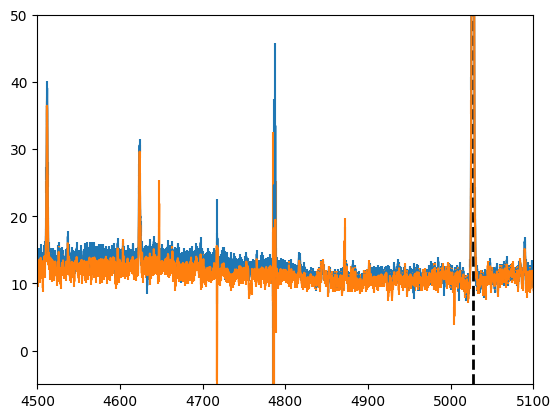

In [27]:
#plt.errorbar(old_all_J2119[1].data['wave'], old_all_J2119[1].data['flux'], np.sqrt(1/old_all_J2119[1].data['ivar']), color='green')
#plt.errorbar(red_J2119[1].data['wave_grid_mid'], red_J2119[1].data['flux'], np.sqrt(1/red_J2119[1].data['ivar']), color='green')
plt.errorbar(red_tell_J2119[1].data['wave'], red_tell_J2119[1].data['flux'], np.sqrt(1/red_tell_J2119[1].data['ivar']))
plt.errorbar(blue_tell_J2119[1].data['wave'], blue_tell_J2119[1].data['flux'], np.sqrt(1/blue_tell_J2119[1].data['ivar']))
plt.xlim(4500, 5100)
plt.ylim(-5, 50)
plt.axvline(wave_cat['[OII]7330']*(1 + z_BN[10]), lw=2, color='black', ls='--')
plt.axvline(wave_cat['[SIII]6312']*(1 + z_BN[10]), lw=2, color='black', ls='--')
plt.axvline(wave_cat['Hb']*(1 + z_BN[10]), lw=2, color='black', ls='--')

In [45]:
from astropy.io import fits
import matplotlib.pyplot as plt
from magE.constutils import *
from magE.functions import gaussian
from lmfit import minimize, Parameters
import corner

#all15_j1146 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J1146/all15/magellan_mage_A/J1146_tellcorr.fits')
#red_j1146 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J1146/red/magellan_mage_A/J1146_red_tellcorr.fits')
#blue_j1146 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J1146/blue/magellan_mage_A/J1146_blue.fits')


all_j0950 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J0950/all/magellan_mage_A/J0950_all_tellcorr.fits')
all_tell_j0950 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J0950/all15/magellan_mage_A/J0950_tellcorr.fits')
red_j0950 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J0950/red/magellan_mage_A/J0950_red.fits')

#all_j1448 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J1448/all/magellan_mage_A/J1448_all.fits')
#red_j1448 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J1448/red/magellan_mage_A/J1448_red.fits')

#all_j2119 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J2119/all/magellan_mage_A/J2119_all.fits')
#red_j2119 = fits.open('/home/benjamin/Documents/pypeit19a/redux_J2119/red/magellan_mage_A/J2119_red.fits')

(-10.0, 20.0)

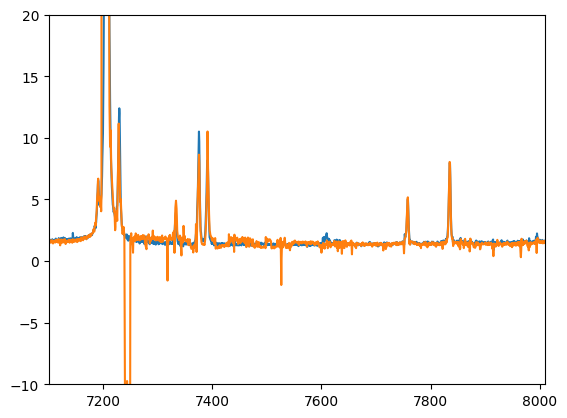

In [55]:
plt.plot(all_j0950[1].data['wave_grid_mid'], all_j0950[1].data['flux'])
plt.plot(all_tell_j0950[1].data['wave_grid_mid'], all_tell_j0950[1].data['flux'])
#plt.plot(red_j0950[1].data['wave'], red_j0950[1].data['flux'])
#plt.plot(blue_j1146[1].data['wave'], blue_j1146[1].data['flux'])
plt.axvline(wave_cat['[OII]3726']*(1 + z_BN[4]), color='black', lw=2., ls='--', alpha=0.2)
plt.axvline(wave_cat['[OII]7330']*(1 + z_BN[4]), color='black', lw=2., ls='--', alpha=0.2)
plt.xlim(7100, 8010)
plt.ylim(-10, 20)

In [155]:
mask_blue_3729 = (blue_j1146[1].data['wave'] > 3930) & (blue_j1146[1].data['wave'] < 3950)
x_blue_3729 = blue_j1146[1].data['wave'][mask_blue_3729]
y_blue_3729 = blue_j1146[1].data['flux'][mask_blue_3729]

mask_all_3729 = (all_j1146[1].data['wave'] > 3930) & (all_j1146[1].data['wave'] < 3950)
x_all_3729 = all_j1146[1].data['wave'][mask_all_3729]
y_all_3729 = all_j1146[1].data['flux'][mask_all_3729]

mask_all_7330 = (all_j1146[1].data['wave'] > 7710) & (all_j1146[1].data['wave'] < 7780)
x_all_7330 = all_j1146[1].data['wave'][mask_all_7330]
y_all_7330 = all_j1146[1].data['flux'][mask_all_7330]

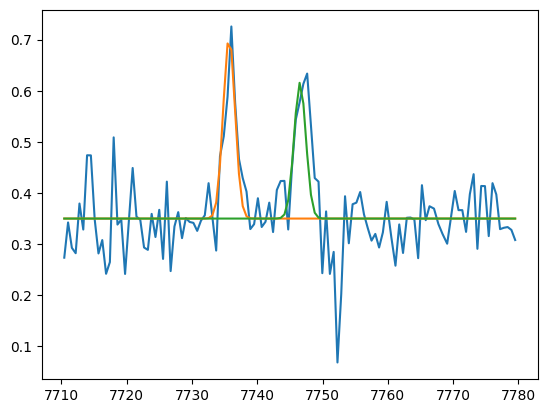

In [174]:
plt.plot(x_all_7330, y_all_7330)
plt.plot(x_all_7330, 0.35 + gaussian(x_all_7330, 0.8, wave_cat['[OII]7319'], z=0.0568, sigma=0.9))
plt.plot(x_all_7330, 0.35 + gaussian(x_all_7330, 0.6, wave_cat['[OII]7330'], z=0.0568, sigma=0.9))

params_all_7330 = Parameters()
params_all_7330.add('z', value=0.0568, min=0.)
params_all_7330.add('flux_7319', value=0.8, min=0.)
params_all_7330.add('flux_7330', value=0.6, min=0.)
params_all_7330.add('sigma', value=0.9, min=0.)
params_all_7330.add('bkg', value=0.35, min=0.)


def residuals_all_7330(params_all_7330, x, data, uncertainty):
    
    z = params_all_7330['z']
    flux_7319 = params_all_7330['flux_7319']
    flux_7330 = params_all_7330['flux_7330']
    sigma = params_all_7330['sigma']
    bkg = params_all_7330['bkg']
    
    x = x_all_7330
    model = bkg + gaussian(x, flux_7319, wave_cat['[OII]7319'], z=z, sigma=sigma) \
                + gaussian(x, flux_7330, wave_cat['[OII]7330'], z=z, sigma=sigma)
    
    return (y_all_7330 - model) / 0.03

In [175]:
np.random.seed(1146)
out_all_7330 = minimize(residuals_all_7330, params_all_7330, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 142.69it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [45.04689198 47.42097557 67.79220688 54.79800958 50.89410825]


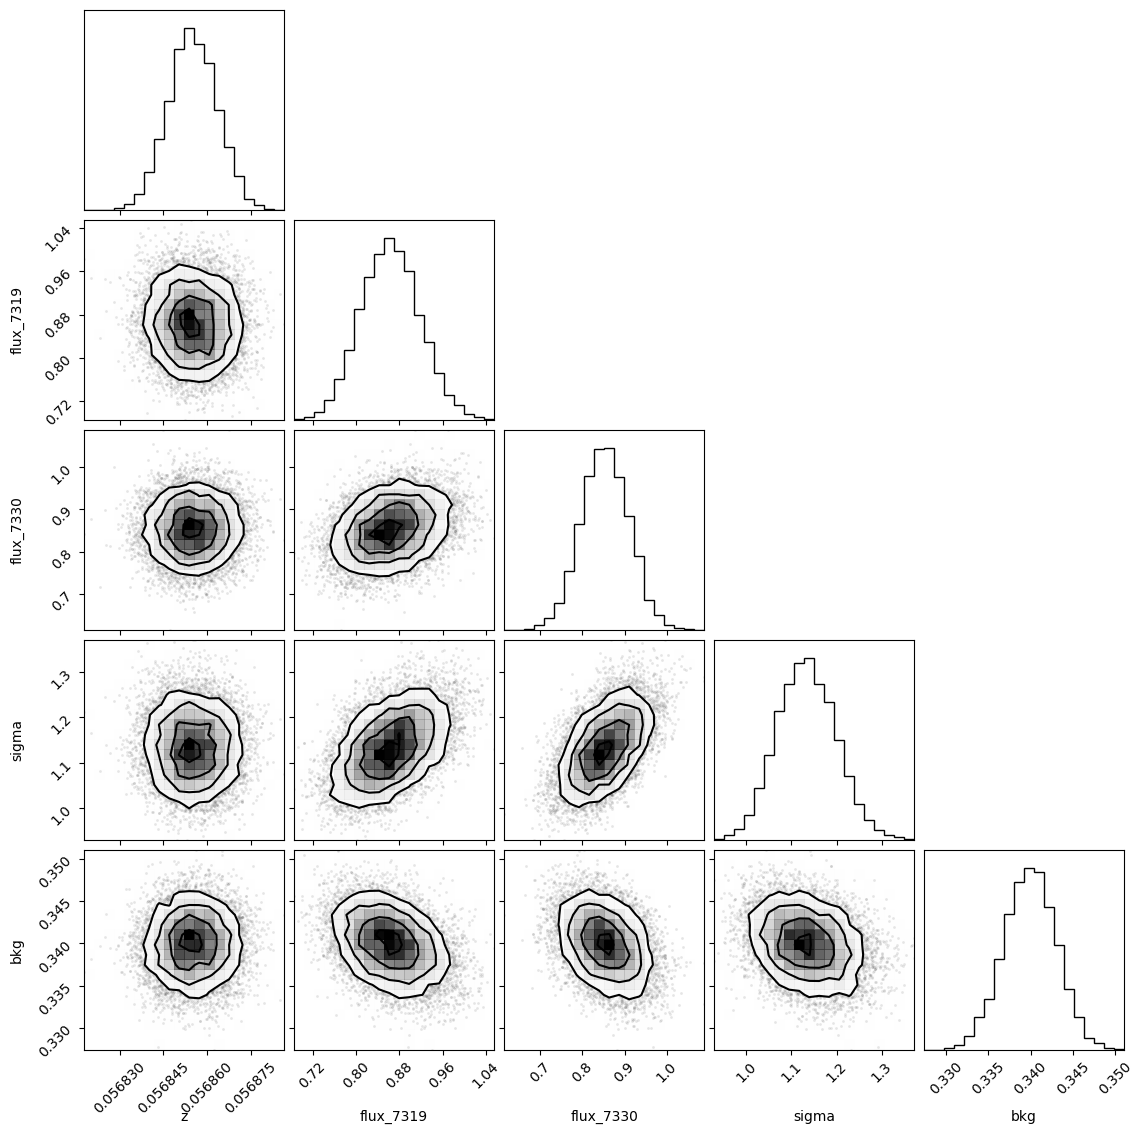

In [176]:
corner.corner(out_all_7330.flatchain, labels=out_all_7330.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [177]:
out_all_7330.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.05685509,8.3301e-06,(0.01%),0.0568,0.00000000,inf,True
flux_7319,0.86299715,0.05455482,(6.32%),0.8,0.00000000,inf,True
flux_7330,0.85361375,0.05622315,(6.59%),0.6,0.00000000,inf,True
sigma,1.13264486,0.06507198,(5.75%),0.9,0.00000000,inf,True
bkg,0.33993838,0.00309581,(0.91%),0.35,0.00000000,inf,True


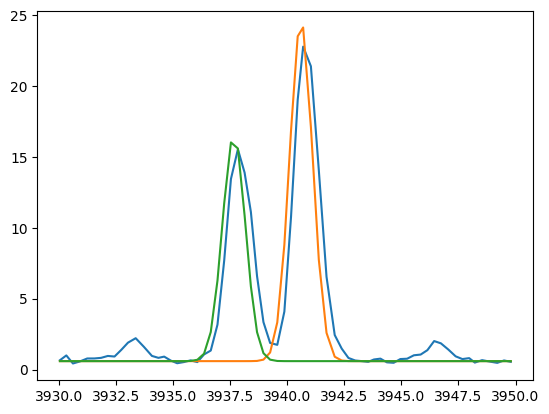

In [127]:
plt.plot(x_blue_3729, y_blue_3729)
plt.plot(x_blue_3729, 0.6 + gaussian(x_blue_3729, 30, wave_cat['[OII]3729'], z=0.0568, sigma=0.5))
plt.plot(x_blue_3729, 0.6 + gaussian(x_blue_3729, 20, wave_cat['[OII]3726'], z=0.0568, sigma=0.5))

params_blue_3729 = Parameters()
params_blue_3729.add('z', value=0.0568, min=0.)
params_blue_3729.add('flux_3729', value=30, min=0.)
params_blue_3729.add('flux_3726', value=20, min=0.)
params_blue_3729.add('sigma', value=0.5, min=0.)
params_blue_3729.add('bkg', value=0.6, min=0.)


def residuals_blue_3729(params_blue_3729, x, data, uncertainty):
    
    z = params_blue_3729['z']
    flux_3729 = params_blue_3729['flux_3729']
    flux_3726 = params_blue_3729['flux_3726']
    sigma = params_blue_3729['sigma']
    bkg = params_blue_3729['bkg']
    
    x = x_blue_3729
    model = bkg + gaussian(x, flux_3726, wave_cat['[OII]3726'], z=z, sigma=sigma) \
                + gaussian(x, flux_3729, wave_cat['[OII]3729'], z=z, sigma=sigma)
    
    return (y_blue_3729 - model) / 0.5

In [128]:
np.random.seed(1146)
out_blue_3729 = minimize(residuals_blue_3729, params_blue_3729, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 143.84it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [27.9837628  53.0138543  45.77173202 46.59950664 80.86731796]


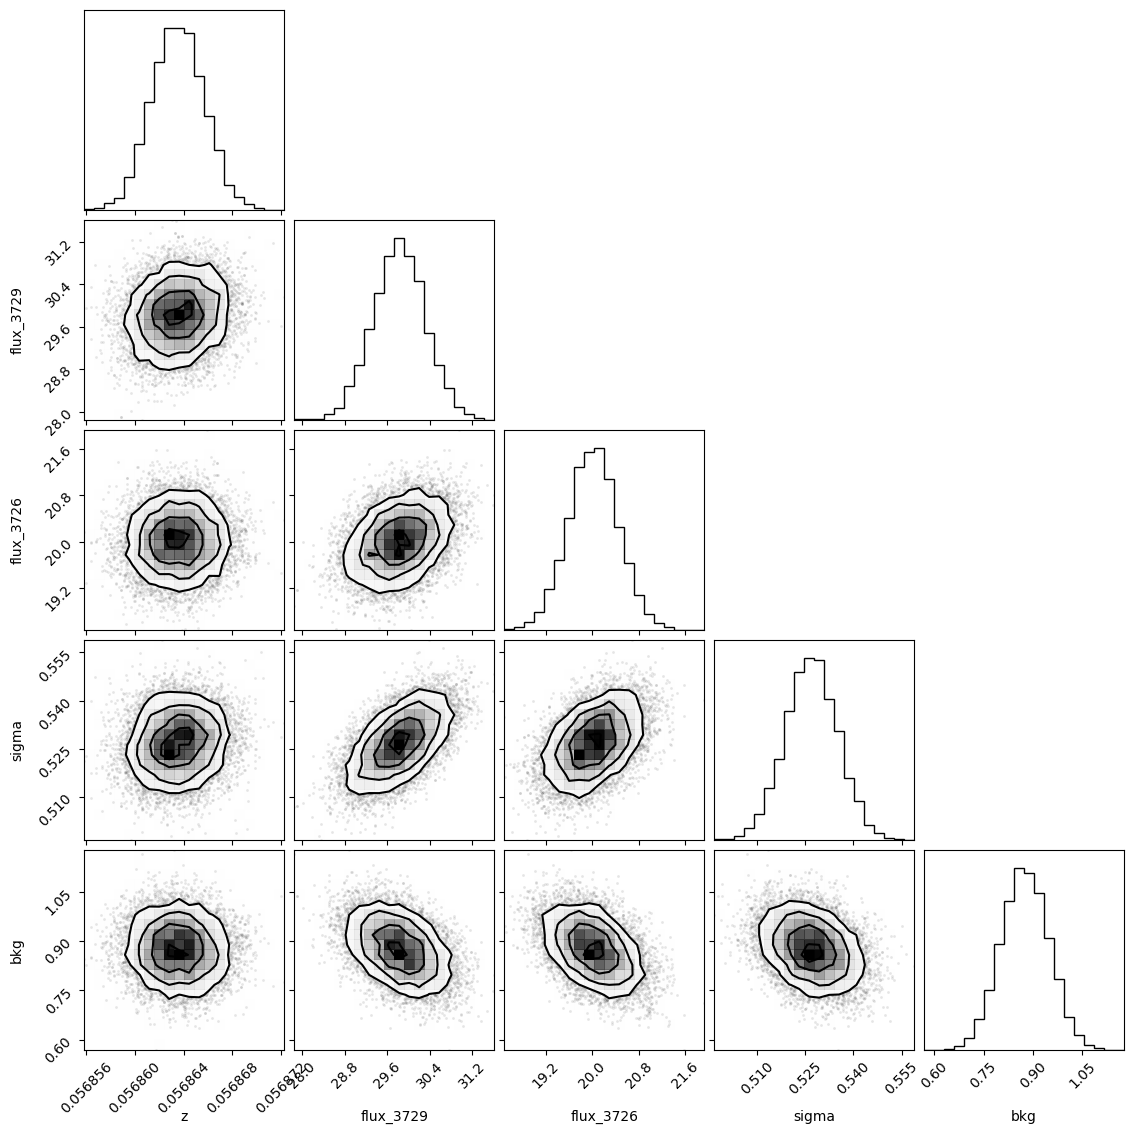

In [134]:
corner.corner(out_blue_3729.flatchain, labels=out_blue_3729.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [129]:
out_blue_3729.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.05686351,2.1504e-06,(0.00%),0.0568,0.00000000,inf,True
flux_3729,29.8285613,0.49279401,(1.65%),30,0.00000000,inf,True
flux_3726,20.0171502,0.42662110,(2.13%),20,0.00000000,inf,True
sigma,0.52689360,0.00799859,(1.52%),0.5,0.00000000,inf,True
bkg,0.87601760,0.07262480,(8.29%),0.6,0.00000000,inf,True


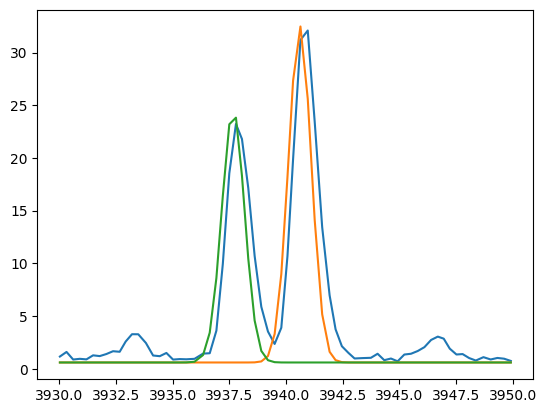

In [141]:
plt.plot(x_all_3729, y_all_3729)
plt.plot(x_all_3729, 0.6 + gaussian(x_all_3729, 40, wave_cat['[OII]3729'], z=0.0568, sigma=0.5))
plt.plot(x_all_3729, 0.6 + gaussian(x_all_3729, 30, wave_cat['[OII]3726'], z=0.0568, sigma=0.5))

params_all_3729 = Parameters()
params_all_3729.add('z', value=0.0568, min=0.)
params_all_3729.add('flux_3729', value=40, min=0.)
params_all_3729.add('flux_3726', value=30, min=0.)
params_all_3729.add('sigma', value=0.5, min=0.)
params_all_3729.add('bkg', value=0.6, min=0.)

def residuals_all_3729(params_all_3729, x, data, uncertainty):
    
    z = params_all_3729['z']
    flux_3729 = params_all_3729['flux_3729']
    flux_3726 = params_all_3729['flux_3726']
    sigma = params_all_3729['sigma']
    bkg = params_all_3729['bkg']
    
    x = x_all_3729
    model = bkg + gaussian(x, flux_3726, wave_cat['[OII]3726'], z=z, sigma=sigma) \
                + gaussian(x, flux_3729, wave_cat['[OII]3729'], z=z, sigma=sigma)
    
    return (y_all_3729 - model) / 0.5

In [142]:
np.random.seed(1146)
out_all_3729 = minimize(residuals_all_3729, params_all_3729, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:16<00:00, 148.17it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 23.35653412  40.46395157  67.93384489  34.94451574 123.98014267]


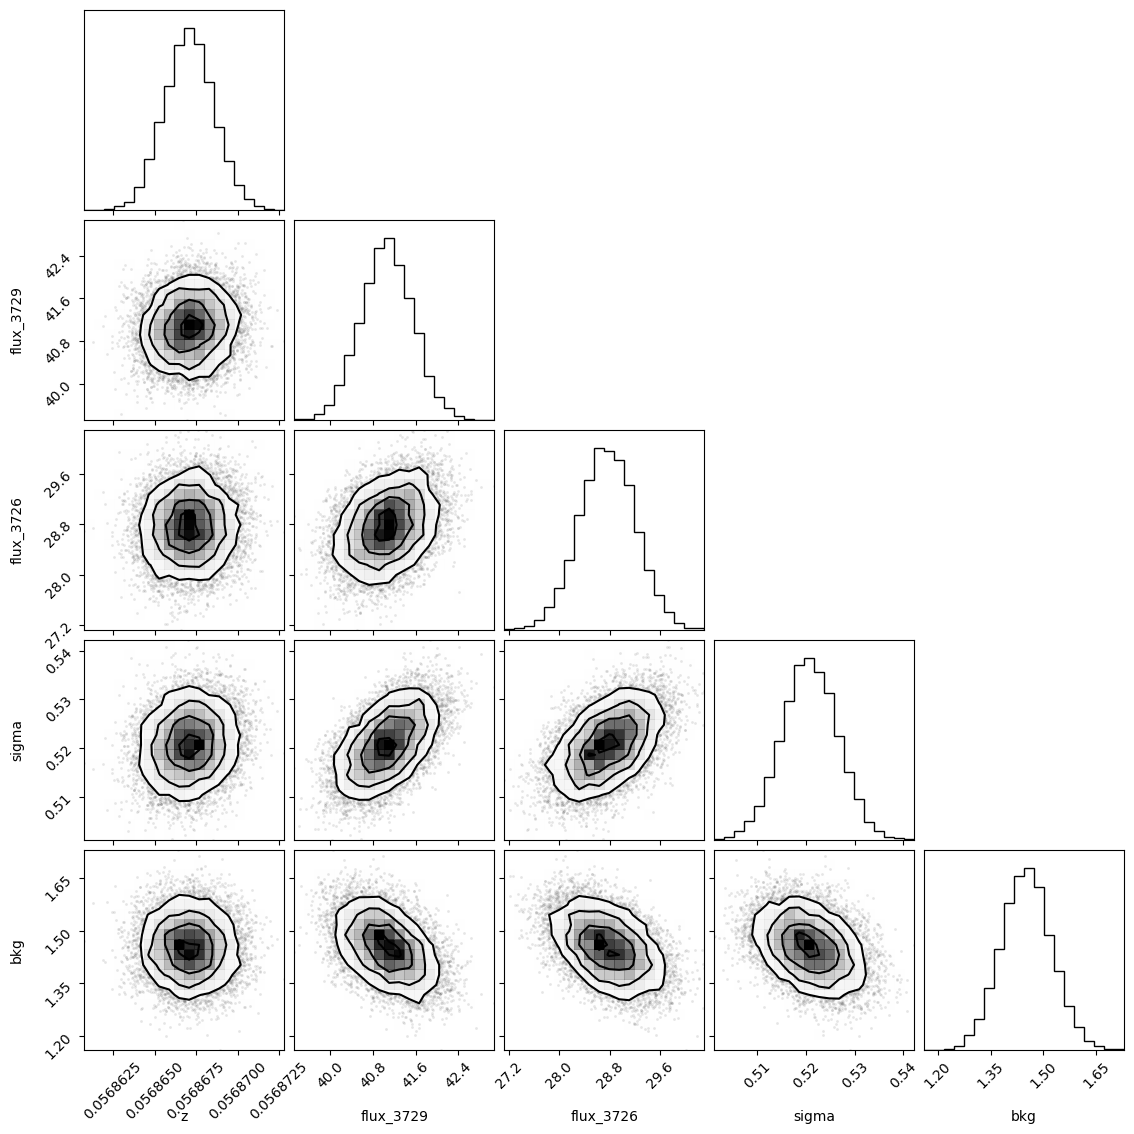

In [143]:
corner.corner(out_all_3729.flatchain, labels=out_all_3729.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [144]:
out_all_3729.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.05686707,1.4869e-06,(0.00%),0.0568,0.00000000,inf,True
flux_3729,41.0563843,0.48632237,(1.18%),40,0.00000000,inf,True
flux_3726,28.7617883,0.43978182,(1.53%),30,0.00000000,inf,True
sigma,0.52072663,0.00573319,(1.10%),0.5,0.00000000,inf,True
bkg,1.45145616,0.07077149,(4.88%),0.6,0.00000000,inf,True


### RO2

In [ ]:
num_3729_blue = (out_blue_3729.flatchain.flux_3726.mean() + out_all_3729.flatchain.flux_3729.mean())
num_3729_all = (out_all_3729.flatchain.flux_3726.mean() + out_all_3729.flatchain.flux_3729.mean())
den_7330_all = (out_all_7330.flatchain.flux_7319.mean() + out_all_7330.flatchain.flux_7330.mean())

In [ ]:
num_3729_all/den_7330_all

40.64474093199341

In [ ]:
num_3729_blue/den_7330_all

35.55376502587462

# Table of em. line measurements

In [1]:
import pandas as pd
import numpy as np
import uncertainties.unumpy as upy

from magE.constutils import wave_cat

em_lines = pd.read_csv('/home/benjamin/Documents/analogs/results/em_lines_final.csv')
new_lines = pd.DataFrame({'galname': em_lines['galname'].to_numpy()}, index=np.arange(0, 18, 1))

In [2]:
for label in em_lines.keys()[1:][::2]:
    if label == 'Hb':
        continue
    new_lines[label] = upy.uarray(em_lines[label], em_lines[label+'_err']) / upy.uarray(em_lines['Hb'], em_lines['Hb_err'])

/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/numpy/lib/function_base.py:2412: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/numpy/lib/function_base.py:2412: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/numpy/lib/function_base.py:2412: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/numpy/lib/function_base.py:2412: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/numpy/lib/function_base.py:2412: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)
/home/benjamin/anaconda3/envs/analo

In [3]:
new_lines.insert(1, 'Hb', upy.uarray(em_lines['Hb'] / 1e-17, em_lines['Hb_err'] / 1e-17))

In [4]:
np.mean(100 * upy.std_devs(new_lines['Hb']) / upy.nominal_values(new_lines['Hb']))

0.3255975601145179

In [5]:
np.mean(100 * upy.std_devs(new_lines['Ha']) / upy.nominal_values(new_lines['Ha']))

0.3824649130488028

In [6]:
waves = []
for emission_line in new_lines.T.index[1:]:
    if emission_line == 'HeII4686':
        emission_line = 'HeII4685'
        waves.append(wave_cat[emission_line])
    else:
        waves.append(wave_cat[emission_line])


In [7]:
final_lines = (new_lines.set_index('galname')).T
final_lines.insert(0, 'lambda', np.array(waves))

In [8]:
cols1 = ['galname', 'lambda', 'J0021', 'J0023', 'J0136', 'J0240', 'J0252', 'J0305']
cols2 = ['galname', 'lambda', 'J0950', 'J1146', 'J1226', 'J1444', 'J1448', 'J1624']
cols3 = ['galname', 'lambda', 'J2101', 'J2119', 'J2212', 'J2215', 'J2225', 'J2337']

In [9]:
final_lines

galname,lambda,J0021,J0023,J0136,J0240,J0252,J0305,J0950,J1146,J1226,J1444,J1448,J1624,J2101,J2119,J2212,J2215,J2225,J2337
Hb,4861.350000,6291+/-11,1372.3+/-3.3,1032+/-4,3919+/-11,873+/-4,1249+/-6,1064.5+/-2.1,179.7+/-0.6,1925.7+/-3.3,800+/-4,10942+/-16,213.5+/-1.2,1392.1+/-3.4,1548+/-7,357.9+/-2.0,234.2+/-0.4,354.2+/-0.7,2105+/-5
[OII]3726,3726.032000,0.608+/-0.009,0.716+/-0.004,0.596+/-0.010,0.270+/-0.004,0.470+/-0.013,0.750+/-0.018,1.362+/-0.010,0.442+/-0.005,0.5838+/-0.0029,0.324+/-0.006,0.4367+/-0.0016,0.458+/-0.011,1.267+/-0.007,0.854+/-0.009,0.707+/-0.013,0.5898+/-0.0034,0.4086+/-0.0032,0.397+/-0.005
[OII]3729,3728.815000,0.931+/-0.008,0.983+/-0.005,0.802+/-0.012,0.252+/-0.004,0.714+/-0.014,0.963+/-0.020,1.614+/-0.010,0.644+/-0.006,0.7144+/-0.0030,0.421+/-0.006,0.5900+/-0.0019,0.556+/-0.014,1.657+/-0.008,1.150+/-0.012,0.914+/-0.014,0.714+/-0.004,0.5335+/-0.0035,0.583+/-0.005
[NeIII]3868,3868.760000,0.3703+/-0.0022,0.5180+/-0.0030,0.623+/-0.007,0.4946+/-0.0035,0.633+/-0.010,0.456+/-0.008,0.804+/-0.004,0.821+/-0.006,0.7754+/-0.0032,0.946+/-0.009,0.5845+/-0.0017,0.379+/-0.007,0.5293+/-0.0032,0.405+/-0.006,0.400+/-0.008,0.5684+/-0.0025,0.5514+/-0.0025,0.6441+/-0.0035
Hd,4101.710277,0.2526+/-0.0016,0.2545+/-0.0020,0.244+/-0.005,0.2520+/-0.0022,0.267+/-0.006,0.255+/-0.006,0.3271+/-0.0021,0.2570+/-0.0022,0.2989+/-0.0013,0.3007+/-0.0033,0.2431+/-0.0009,0.209+/-0.006,0.2793+/-0.0021,0.2189+/-0.0031,0.230+/-0.006,0.2551+/-0.0016,0.2724+/-0.0016,0.2566+/-0.0022
Hg,4340.472000,0.4759+/-0.0018,0.4692+/-0.0024,0.486+/-0.005,0.4424+/-0.0028,0.511+/-0.006,0.467+/-0.006,0.4975+/-0.0019,0.4670+/-0.0030,0.4800+/-0.0014,0.497+/-0.004,0.4063+/-0.0010,0.442+/-0.007,0.5541+/-0.0027,0.348+/-0.004,0.466+/-0.005,0.4796+/-0.0020,0.4796+/-0.0020,0.5036+/-0.0028
[OIII]4363,4363.209000,0.0399+/-0.0013,0.0746+/-0.0014,0.124+/-0.004,0.1351+/-0.0018,0.130+/-0.004,0.071+/-0.005,0.0740+/-0.0011,0.1743+/-0.0019,0.1263+/-0.0007,0.1969+/-0.0024,0.0829+/-0.0005,0.061+/-0.005,0.0515+/-0.0014,0.0558+/-0.0020,0.044+/-0.004,0.0967+/-0.0010,0.1165+/-0.0011,0.2018+/-0.0022
HeI4471,4471.480200,0.0376+/-0.0011,0.0376+/-0.0013,nan+/-nan,0.0383+/-0.0012,nan+/-nan,nan+/-nan,0.0391+/-0.0009,0.0344+/-0.0010,0.0367+/-0.0004,0.0418+/-0.0011,0.0306+/-0.0004,nan+/-nan,0.0383+/-0.0012,0.0331+/-0.0014,nan+/-nan,0.0381+/-0.0007,0.0360+/-0.0007,0.0411+/-0.0012
[FeIII]4658,4658.050000,0.0116+/-0.0007,0.0068+/-0.0013,nan+/-nan,0.0059+/-0.0008,nan+/-nan,nan+/-nan,0.0084+/-0.0007,nan+/-nan,0.0078+/-0.0005,nan+/-nan,0.00542+/-0.00026,nan+/-nan,0.0107+/-0.0009,0.0060+/-0.0010,0.0143+/-0.0034,0.0106+/-0.0006,0.0079+/-0.0006,0.0074+/-0.0010
HeII4686,4685.710000,0.0104+/-0.0007,0.0082+/-0.0013,nan+/-nan,0.0257+/-0.0009,nan+/-nan,nan+/-nan,0.0113+/-0.0007,0.0098+/-0.0008,0.0125+/-0.0005,0.0044+/-0.0006,0.00980+/-0.00028,nan+/-nan,0.0089+/-0.0009,0.0099+/-0.0011,nan+/-nan,0.0072+/-0.0006,0.0121+/-0.0006,0.0062+/-0.0010


In [12]:
final_lines.to_latex(columns=cols3, float_format='%.4f')

'\\begin{tabular}{lrllllll}\n\\toprule\ngalname & lambda & J2101 & J2119 & J2212 & J2215 & J2225 & J2337 \\\\\n\\midrule\nHb & 4861.3500 & 1392.1+/-3.4 & 1548+/-7 & 357.9+/-2.0 & 234.2+/-0.4 & 354.2+/-0.7 & 2105+/-5 \\\\\n[OII]3726 & 3726.0320 & 1.267+/-0.007 & 0.854+/-0.009 & 0.707+/-0.013 & 0.5898+/-0.0034 & 0.4086+/-0.0032 & 0.397+/-0.005 \\\\\n[OII]3729 & 3728.8150 & 1.657+/-0.008 & 1.150+/-0.012 & 0.914+/-0.014 & 0.714+/-0.004 & 0.5335+/-0.0035 & 0.583+/-0.005 \\\\\n[NeIII]3868 & 3868.7600 & 0.5293+/-0.0032 & 0.405+/-0.006 & 0.400+/-0.008 & 0.5684+/-0.0025 & 0.5514+/-0.0025 & 0.6441+/-0.0035 \\\\\nHd & 4101.7103 & 0.2793+/-0.0021 & 0.2189+/-0.0031 & 0.230+/-0.006 & 0.2551+/-0.0016 & 0.2724+/-0.0016 & 0.2566+/-0.0022 \\\\\nHg & 4340.4720 & 0.5541+/-0.0027 & 0.348+/-0.004 & 0.466+/-0.005 & 0.4796+/-0.0020 & 0.4796+/-0.0020 & 0.5036+/-0.0028 \\\\\n[OIII]4363 & 4363.2090 & 0.0515+/-0.0014 & 0.0558+/-0.0020 & 0.044+/-0.004 & 0.0967+/-0.0010 & 0.1165+/-0.0011 & 0.2018+/-0.0022 \\\\\nHeI

---

# Table of em. line kinematics

In [1]:
import pandas as pd
import numpy as np
import uncertainties.unumpy as upy

# Read velocity data catalog
em_line_model = pd.read_csv('/home/benjamin/Documents/analogs/results/vel_catalog.csv')

# Mask to order by RA
mask_vel = np.argsort(em_line_model['galname'])

# Read BIC catalog
bic_catalog = pd.read_csv('/home/benjamin/Documents/analogs/results/comp_test.csv')

In [2]:
em_line_model

,galname,z_nar,dV,dV_err,FWHM_nar,FWHM_nar_err,FWHM_brd,FWHM_brd_err
0,J0021,0.098677,3.401325,0.567910,161.274295,0.651539,421.819692,2.468141
1,J0023,0.053380,-32.695890,3.511657,88.157011,0.407650,268.034255,14.443311
2,J0136,0.059744,7.456989,0.987992,104.954915,0.796290,217.139921,4.775056
3,J0240,0.082536,-18.117825,0.493231,81.374836,0.678535,274.608443,1.539495
4,J0252,0.028290,4.744921,0.843998,103.970461,0.823019,208.043364,4.266165
5,J0305,0.085861,-4.061623,1.242909,73.998673,3.589364,231.005920,8.366744
6,J0950,0.098044,-20.870696,0.501271,108.340755,0.710736,273.368129,2.134499
7,J1226,0.094510,2.560848,1.024998,95.966713,0.424332,258.688233,5.731451
8,J1146,0.056789,21.130298,0.662895,63.610429,0.900907,77.088277,1.225853
9,J1444,0.039041,5.277761,1.740231,44.192506,1.698460,153.990702,9.492727


In [3]:
# Adding velocity data to BIC catalog
bic_catalog['z_nar'] = em_line_model['z_nar'][mask_vel]
bic_catalog['dV'] = upy.uarray(em_line_model['dV'][mask_vel], em_line_model['dV_err'][mask_vel])
bic_catalog['FWHM_nar'] = upy.uarray(em_line_model['FWHM_nar'][mask_vel], em_line_model['FWHM_nar_err'][mask_vel])
bic_catalog['FWHM_brd'] = upy.uarray(em_line_model['FWHM_brd'][mask_vel], em_line_model['FWHM_brd_err'][mask_vel])

In [4]:
bic_catalog

,galname,BIC_1_2,BIC_2_3,z_nar,dV,FWHM_nar,FWHM_brd
0,J0021,417.800281,30.712356,0.098677,3.4+/-0.6,161.3+/-0.7,421.8+/-2.5
1,J0023,61.035263,22.557389,0.053380,-32.7+/-3.5,88.2+/-0.4,268+/-14
2,J0136,248.018553,3.756324,0.059744,7.5+/-1.0,105.0+/-0.8,217+/-5
3,J0240,324.039143,92.921033,0.082536,-18.1+/-0.5,81.4+/-0.7,274.6+/-1.5
4,J0252,282.031769,24.842856,0.028290,4.7+/-0.8,104.0+/-0.8,208+/-4
5,J0305,168.025747,14.481587,0.085861,-4.1+/-1.2,74+/-4,231+/-8
6,J0950,154.732881,120.633046,0.098044,-20.9+/-0.5,108.3+/-0.7,273.4+/-2.1
7,J1146,195.896976,-17.370937,0.094510,21.1+/-0.7,63.6+/-0.9,77.1+/-1.2
8,J1226,210.089256,42.791755,0.056789,2.6+/-1.0,96.0+/-0.4,259+/-6
9,J1444,125.347513,-113.619662,0.039041,5.3+/-1.7,44.2+/-1.7,154+/-9


In [5]:
# To latex
bic_catalog.to_latex(index=False, float_format='%.3f')

'\\begin{tabular}{lrrrlll}\n\\toprule\ngalname & BIC_1_2 & BIC_2_3 & z_nar & dV & FWHM_nar & FWHM_brd \\\\\n\\midrule\nJ0021 & 417.800 & 30.712 & 0.099 & 3.4+/-0.6 & 161.3+/-0.7 & 421.8+/-2.5 \\\\\nJ0023 & 61.035 & 22.557 & 0.053 & -32.7+/-3.5 & 88.2+/-0.4 & 268+/-14 \\\\\nJ0136 & 248.019 & 3.756 & 0.060 & 7.5+/-1.0 & 105.0+/-0.8 & 217+/-5 \\\\\nJ0240 & 324.039 & 92.921 & 0.083 & -18.1+/-0.5 & 81.4+/-0.7 & 274.6+/-1.5 \\\\\nJ0252 & 282.032 & 24.843 & 0.028 & 4.7+/-0.8 & 104.0+/-0.8 & 208+/-4 \\\\\nJ0305 & 168.026 & 14.482 & 0.086 & -4.1+/-1.2 & 74+/-4 & 231+/-8 \\\\\nJ0950 & 154.733 & 120.633 & 0.098 & -20.9+/-0.5 & 108.3+/-0.7 & 273.4+/-2.1 \\\\\nJ1146 & 195.897 & -17.371 & 0.095 & 21.1+/-0.7 & 63.6+/-0.9 & 77.1+/-1.2 \\\\\nJ1226 & 210.089 & 42.792 & 0.057 & 2.6+/-1.0 & 96.0+/-0.4 & 259+/-6 \\\\\nJ1444 & 125.348 & -113.620 & 0.039 & 5.3+/-1.7 & 44.2+/-1.7 & 154+/-9 \\\\\nJ1448 & 73.346 & 159.534 & 0.028 & 30.6+/-0.4 & 94.43+/-0.26 & 227.8+/-1.6 \\\\\nJ1624 & 165.867 & 9.315 & 0.032 & 

---

# Table of EW

In [1]:
import pandas as pd

pd.read_csv('/home/benjamin/Documents/analogs/results/ew_lines.csv')

,galname,[OII]3726,[OII]3726_err,[OII]3726_nar,[OII]3726_nar_err,[OII]3726_brd,[OII]3726_brd_err,[OII]3729,[OII]3729_err,[OII]3729_nar,...,[SIII]9069_nar,[SIII]9069_nar_err,[SIII]9069_brd,[SIII]9069_brd_err,[SIII]9532,[SIII]9532_err,[SIII]9532_nar,[SIII]9532_nar_err,[SIII]9532_brd,[SIII]9532_brd_err
0,J0021,33.048526,0.284529,32.382183,0.282028,0.666343,0.003798,51.148867,0.501134,36.076587,...,11.638238,1.106319,49.606650,1.698218,136.930612,14.867477,136.930612,14.867477,136.930612,14.867477
1,J0023,107.010134,2.879316,106.933832,2.877342,0.076302,0.002013,146.635550,3.922683,146.563855,...,19.016802,1.410225,60.044878,2.494948,219.972901,15.038858,219.972901,15.038858,219.972901,15.038858
2,J0136,58.789145,4.267391,57.928877,4.206744,0.860269,0.061546,80.283879,5.799211,79.068991,...,3.701086,1.913391,33.546421,3.249189,61.292604,6.823923,61.292604,6.823923,61.292604,6.823923
3,J0240,55.710825,2.370131,48.271576,1.839752,7.439250,1.178640,50.838199,2.276546,47.247789,...,11.952483,3.367577,83.713528,7.893477,100.151961,21.524547,100.151961,21.524547,100.151961,21.524547
4,J0252,40.470653,2.867173,39.545776,2.805742,0.924878,0.063467,55.760454,4.028538,54.677734,...,2.552376,1.781211,39.961842,4.033593,107.071394,6.273300,107.071394,6.273300,107.071394,6.273300
5,J0305,39.990353,1.431603,38.999898,1.403704,0.990454,0.031494,53.420745,1.881137,52.562708,...,7.372799,2.037433,22.377030,3.585248,131.035689,49.388537,131.035689,49.388537,131.035689,49.388537
6,J0950,34.904885,0.397710,29.577334,0.279326,5.327551,0.263045,41.876354,0.479682,33.219186,...,25.803455,1.693908,31.594191,2.216596,121.599714,13.760386,121.599714,13.760386,121.599714,13.760386
7,J1146,26.953191,0.904097,25.151467,0.695321,1.801724,0.548486,38.288331,1.177151,32.184095,...,1.460849,0.041477,22.807370,1.126982,50.393440,4.645203,50.393440,4.645203,50.393440,4.645203
8,J1226,56.323977,0.721231,56.299342,0.720951,0.024636,0.000297,74.574114,0.939548,74.545233,...,8.348764,1.498330,69.118798,2.554759,155.323921,25.274276,155.323921,25.274276,155.323921,25.274276
9,J1444,42.552832,1.584131,42.444947,1.580499,0.107885,0.003819,52.093534,1.922165,51.997184,...,3.560091,2.746044,55.874062,7.064470,122.263160,8.478079,122.263160,8.478079,122.263160,8.478079


---

# Table of extinctions

In [2]:
import pandas as pd
from astropy.io import fits
import numpy as np
from magE.constutils import *
import uncertainties.unumpy as upy

# Reading Galactic extinction
magePath = '/home/benjamin/Documents/analogs/'
ext_gal = pd.read_table(magePath+'dust/extinction_new.tbl',
                             comment='#', delim_whitespace=True)
for key in ext_gal.keys():
    ext_gal.rename(columns={key: key[1:]}, inplace=True)
ext_gal.drop([0, 1], axis=0, inplace=True)
print('Extinction rable read.')

# Reading Balmer decrements
ext_cal = pd.read_csv(magePath+'results/bal_decrements.csv')

# Reading SED fitting attenuation
ext_sed = fits.open('/home/benjamin/Documents/sed_fitting/old_pop_late_burst/results.fits')

Extinction rable read.


In [3]:
# Ordering galactic extinction by RA (Calzetti)
E_BV_galarray = []
E_BV_galerr = []
for galname in ext_cal['galname']:
    igal = np.argmax(ext_gal['objname'] == galname)
    E_BV_galarray.append(float(ext_gal['E_B_V_SandF'][igal + 2]))
    E_BV_galerr.append(float(ext_gal['stdev_E_B_V_SandF'][igal + 2]))

In [4]:
# Ordering SED extinction by RA
E_BV_SED_array = []
E_BV_SED_err = []

for galname in ext_cal['galname']:
    
    igal_ext = np.argmax(np.array(galnames) == galname)
    
    if galname == 'J2212':
        igal = np.argmax(ext_sed[1].data['id'] == 'J2212+0006')
    elif  galname != 'J2212':
        igal = np.argmax(ext_sed[1].data['id'] == galnames_ext[igal_ext])

    E_BV_SED_array.append(ext_sed[1].data['bayes.attenuation.E_BVs'][igal] / 0.44)
    E_BV_SED_err.append(ext_sed[1].data['bayes.attenuation.E_BVs_err'][igal] / 0.44)

In [5]:
extinction_dict = {'ID': ext_cal['galname'].to_numpy(dtype='str'),
                   'E_BV_gal': upy.uarray(np.array(E_BV_galarray), np.array(E_BV_galerr)),
                   'E_BV_SED': upy.uarray(np.array(E_BV_SED_array), np.array(E_BV_SED_err)),
                   'E_BV_Cal': upy.uarray(ext_cal['E_BV'].to_numpy(), ext_cal['E_BV_err'].to_numpy())
}

In [6]:
extinction = pd.DataFrame(data=extinction_dict, index=None)

In [7]:
extinction.to_latex(index=False, float_format='%.3f')

'\\begin{tabular}{llll}\n\\toprule\nID & E_BV_gal & E_BV_SED & E_BV_Cal \\\\\n\\midrule\nJ0021 & 0.0212+/-0.0008 & 0.29+/-0.05 & 0.1240+/-0.0026 \\\\\nJ0023 & 0.0422+/-0.0013 & 0.3000+/-0.0011 & 0.11+/-0.07 \\\\\nJ0136 & 0.0242+/-0.0010 & 0.300+/-0.006 & 0.070+/-0.008 \\\\\nJ0240 & 0.0263+/-0.0009 & 0.25+/-0.09 & 0.119+/-0.004 \\\\\nJ0252 & 0.0580+/-0.0033 & 0.3000+/-0.0006 & -0.020+/-0.008 \\\\\nJ0305 & 0.0671+/-0.0015 & 0.3000+/-0.0004 & 0.170+/-0.010 \\\\\nJ0950 & 0.0475+/-0.0014 & 0.28+/-0.06 & 0.3113+/-0.0034 \\\\\nJ1146 & 0.0210+/-0.0008 & 0.299+/-0.012 & 0.19+/-0.10 \\\\\nJ1226 & 0.0158+/-0.0006 & 0.26+/-0.09 & -0.0827+/-0.0023 \\\\\nJ1444 & 0.0266+/-0.0007 & 0.09+/-0.08 & -0.050+/-0.008 \\\\\nJ1448 & 0.0469+/-0.0015 & 0.27+/-0.08 & -0.2060+/-0.0022 \\\\\nJ1624 & 0.0771+/-0.0023 & 0.27+/-0.07 & 0.066+/-0.009 \\\\\nJ2101 & 0.0487+/-0.0019 & 0.300+/-0.008 & 0.081+/-0.004 \\\\\nJ2119 & 0.0680+/-0.0030 & 0.30000+/-0.00005 & 0.096+/-0.007 \\\\\nJ2212 & 0.0501+/-0.0020 & 0.29+/-0.05 &

In [7]:
import os
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)
import pyneb as pn

In [23]:
rc_min = pn.RedCorr(E_BV=np.min(np.array(E_BV_galarray)), R_V=3.1, law='CCM89')
100 * round(1 - 10**(-0.4 * np.min(np.array(E_BV_galarray)) * rc_min.getCorr(wave_cat['Hb'])), 3)

1.5

In [24]:
rc_max = pn.RedCorr(E_BV=np.max(np.array(E_BV_galarray)), R_V=3.1, law='CCM89')
100 * round(1 - 10**(-0.4 * np.max(np.array(E_BV_galarray)) * rc_max.getCorr(wave_cat['Hb'])), 3)

8.799999999999999

In [17]:
np.sort(np.array(E_BV_galarray))

array([0.0158, 0.021 , 0.0212, 0.0242, 0.0263, 0.0266, 0.0323, 0.0422,
       0.0469, 0.0475, 0.0487, 0.0501, 0.058 , 0.064 , 0.0644, 0.0671,
       0.068 , 0.0771])

---

# Spectral SNR

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from magE.plotutils import *
from magE.constutils import *

snr_lco = pd.read_csv('./lco_etc_out.dat', sep=' ')


J0021 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J0021.csv')
wave_J0021 = J0021['wave'].to_numpy()
flux_J0021 = J0021['flux'].to_numpy()
err_J0021 = J0021['noise'].to_numpy()

J0023 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J0023.csv')
wave_J0023 = J0023['wave'].to_numpy()
flux_J0023 = J0023['flux'].to_numpy()
err_J0023 = J0023['noise'].to_numpy()

J0136 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J0136.csv')
wave_J0136 = J0136['wave'].to_numpy()
flux_J0136 = J0136['flux'].to_numpy()
err_J0136 = J0136['noise'].to_numpy()

J0240 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J0240.csv')
wave_J0240 = J0240['wave'].to_numpy()
flux_J0240 = J0240['flux'].to_numpy()
err_J0240 = J0240['noise'].to_numpy()

J0252 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J0252.csv')
wave_J0252 = J0252['wave'].to_numpy()
flux_J0252 = J0252['flux'].to_numpy()
err_J0252 = J0252['noise'].to_numpy()

J0305 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J0305.csv')
wave_J0305 = J0305['wave'].to_numpy()
flux_J0305 = J0305['flux'].to_numpy()
err_J0305 = J0305['noise'].to_numpy()

J0950 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J0950.csv')
wave_J0950 = J0950['wave'].to_numpy()
flux_J0950 = J0950['flux'].to_numpy()
err_J0950 = J0950['noise'].to_numpy()

J1146 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J1146.csv')
wave_J1146 = J1146['wave'].to_numpy()
flux_J1146 = J1146['flux'].to_numpy()
err_J1146 = J1146['noise'].to_numpy()

J1226 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J1226.csv')
wave_J1226 = J1226['wave'].to_numpy()
flux_J1226 = J1226['flux'].to_numpy()
err_J1226 = J1226['noise'].to_numpy()

J1444 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J1444.csv')
wave_J1444 = J1444['wave'].to_numpy()
flux_J1444 = J1444['flux'].to_numpy()
err_J1444 = J1444['noise'].to_numpy()

J1448 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J1448.csv')
wave_J1448 = J1448['wave'].to_numpy()
flux_J1448 = J1448['flux'].to_numpy()
err_J1448 = J1448['noise'].to_numpy()

J1624 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J1624.csv')
wave_J1624 = J1624['wave'].to_numpy()
flux_J1624 = J1624['flux'].to_numpy()
err_J1624 = J1624['noise'].to_numpy()

J2101 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J2101.csv')
wave_J2101 = J2101['wave'].to_numpy()
flux_J2101 = J2101['flux'].to_numpy()
err_J2101 = J2101['noise'].to_numpy()

J2119 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J2119.csv')
wave_J2119 = J2119['wave'].to_numpy()
flux_J2119 = J2119['flux'].to_numpy()
err_J2119 = J2119['noise'].to_numpy()

J2212 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J2212.csv')
wave_J2212 = J2212['wave'].to_numpy()
flux_J2212 = J2212['flux'].to_numpy()
err_J2212 = J2212['noise'].to_numpy()

J2215 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J2215.csv')
wave_J2215 = J2215['wave'].to_numpy()
flux_J2215 = J2215['flux'].to_numpy()
err_J2215 = J2215['noise'].to_numpy()

J2225 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J2225.csv')
wave_J2225 = J2225['wave'].to_numpy()
flux_J2225 = J2225['flux'].to_numpy()
err_J2225 = J2225['noise'].to_numpy()

J2337 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J2337.csv')
wave_J2337 = J2337['wave'].to_numpy()
flux_J2337 = J2337['flux'].to_numpy()
err_J2337 = J2337['noise'].to_numpy()

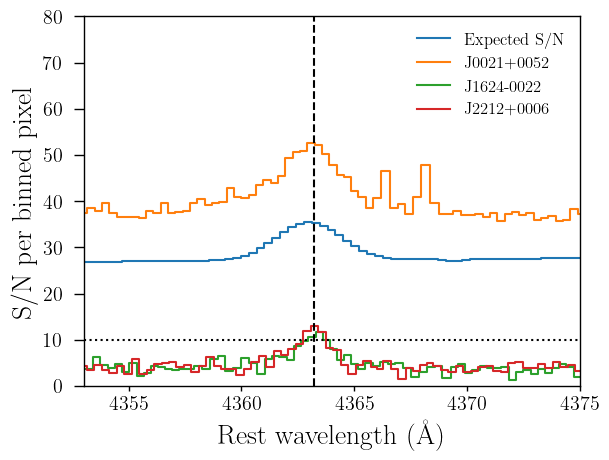

In [57]:
texPlot('on')
plt.step(snr_lco['Wavelength_[A]'], snr_lco['S/N_Aperture'], where='mid', label='Expected S/N')
plt.step(wave_J0021 / (1 + 0.0987), flux_J0021 / err_J0021, label='J0021+0052', where='mid')
#plt.plot(wave_J0023 / (1 + 0.0534), flux_J0023 / err_J0023, label='J0023')
#plt.plot(wave_J0136 / (1 + 0.0597), flux_J0136 / err_J0136, label='J0136')
#plt.plot(wave_J0240 / (1 + 0.0825), flux_J0240 / err_J0240, label='J0240')
#plt.plot(wave_J0252 / (1 + 0.0283), flux_J0252 / err_J0252, label='J0252')
#plt.plot(wave_J0305 / (1 + 0.0859), flux_J0305 / err_J0305, label='J0305')
#plt.plot(wave_J0950 / (1 + 0.0981), flux_J0950 / err_J0950, label='J0950')
#plt.plot(wave_J1146 / (1 + 0.0568), flux_J1146 / err_J1146, label='J1146')
#plt.plot(wave_J1226 / (1 + 0.0945), flux_J1226 / err_J1226, label='J1226')
#plt.plot(wave_J1444 / (1 + 0.0390), flux_J1444 / err_J1444, label='J1444')
#plt.plot(wave_J1448 / (1 + 0.0277), flux_J1448 / err_J1448, label='J1448')
plt.step(wave_J1624 / (1 + 0.0316), flux_J1624 / err_J1624, label='J1624-0022', where='mid')
#plt.plot(wave_J2101 / (1 + 0.1965), flux_J2101 / err_J2101, label='J2101')
#plt.plot(wave_J2119 / (1 + 0.0340), flux_J2119 / err_J2119, label='J2119')
plt.step(wave_J2212 / (1 + 0.1774), flux_J2212 / err_J2212, label='J2212+0006', where='mid')
#plt.plot(wave_J2215 / (1 + 0.0778), flux_J2215 / err_J2215, label='J2215')
#plt.plot(wave_J2225 / (1 + 0.0670), flux_J2225 / err_J2225, label='J2225')
#plt.plot(wave_J2337 / (1 + 0.0720), flux_J2337 / err_J2337, label='J2337')

plt.axhline(10, ls=':')
plt.axvline(wave_cat['[OIII]4363'], ls='--')
plt.xlim(4353, 4375)
plt.ylim(0, 80)
plt.xlabel('Rest wavelength (\AA)')
plt.ylabel('S/N per binned pixel')
plt.legend(fontsize=12)
#plt.savefig('/home/benjamin/Documents/analogs/imges/sn_ratio_oiii.pdf', bbox_inches='tight')

# Table of photometric data

In [33]:
import pandas as pd
import uncertainties.unumpy as upy

photo_data = pd.read_csv('/home/benjamin/Documents/sed_fitting/input_new.txt', sep=' ').drop([16])

In [16]:
photo_data

,id,redshift,u_prime,u_prime_err,g_prime,g_prime_err,r_prime,r_prime_err,i_prime,i_prime_err,z_prime,z_prime_err
0,J2225-0011,0.067,0.087485,0.001729,0.157123,0.001039,0.091337,0.000963,0.186609,0.001634,0.124366,0.005425
1,J2215+0002,0.077,0.050301,0.001759,0.079577,0.000764,0.062841,0.000964,0.129084,0.001453,0.081443,0.008529
2,J0240-0828,0.082,0.061175,0.001887,0.091863,0.000995,0.053160,0.001024,0.151000,0.001506,0.048801,0.005151
3,J0021+0052,0.098,0.335951,0.003368,0.400014,0.001710,0.360985,0.001833,0.592059,0.002861,0.402117,0.006498
4,J0950+0042,0.098,0.107755,0.001846,0.134521,0.000954,0.116242,0.001029,0.198590,0.001693,0.123958,0.005341
5,J1146+0053,0.057,0.024193,0.001408,0.062175,0.000679,0.034815,0.001067,0.052716,0.001335,0.056362,0.004349
6,J1226+0415,0.094,0.058095,0.001896,0.073828,0.000855,0.055152,0.001045,0.122262,0.001558,0.060705,0.006121
7,J1444+0409,0.039,0.023486,0.002177,0.062444,0.000699,0.027257,0.001077,0.026726,0.001229,0.057913,0.016071
8,J1448-0110,0.027,0.394925,0.003143,0.944276,0.003067,0.636142,0.002502,0.518669,0.002663,0.468867,0.006373
9,J2101-0555,0.196,0.042342,0.001617,0.064180,0.000772,0.107227,0.001109,0.100593,0.001753,0.079561,0.005928


In [36]:
photo_data = fits.open('/home/benjamin/Documents/sed_fitting/photo_sdss_new_ordered.fits')[1].data
photo_data['name']

chararray(['J0021+0052', 'J0023-0948', 'J0136-0037', 'J0240-0828',
           'J0252+0114', 'J0305+0040', 'J0950+0042', 'J1146+0053',
           'J1226+0415', 'J1444+0409', 'J1448-0110', 'J1624-0022',
           'J2101-0555', 'J2119+0052', 'J2212+0006', 'J2215+0002',
           'J2225-0011', 'J2337-0010'], dtype='<U32')

In [40]:
pd.DataFrame({'id': photo_data['name'],
             'SDSS_u': upy.uarray(photo_data['cModelMag_u'], photo_data['cModelMagErr_u']),
              'SDSS_g': upy.uarray(photo_data['cModelMag_g'], photo_data['cModelMagErr_g']),
              'SDSS_r': upy.uarray(photo_data['cModelMag_r'], photo_data['cModelMagErr_r']),
              'SDSS_i': upy.uarray(photo_data['cModelMag_i'], photo_data['cModelMagErr_i']),
              'SDSS_z': upy.uarray(photo_data['cModelMag_z'], photo_data['cModelMagErr_z']),
}).to_latex(float_format='{:.3f}'.format)

/tmp/ipykernel_235708/3893183128.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  pd.DataFrame({'id': photo_data['name'],


'\\begin{tabular}{lllllll}\n\\toprule\n{} &          id &          SDSS\\_u &            SDSS\\_g &          SDSS\\_r &          SDSS\\_i &          SDSS\\_z \\\\\n\\midrule\n0  &  J0021+0052 &  17.624+/-0.011 &    17.395+/-0.005 &  17.506+/-0.006 &  16.969+/-0.005 &  17.369+/-0.018 \\\\\n1  &  J0023-0948 &  18.514+/-0.026 &    17.550+/-0.006 &  17.882+/-0.010 &  17.531+/-0.011 &    17.34+/-0.05 \\\\\n2  &  J0136-0037 &    20.28+/-0.05 &    19.270+/-0.011 &  19.792+/-0.022 &  19.321+/-0.021 &    19.40+/-0.06 \\\\\n3  &  J0240-0828 &  19.474+/-0.033 &    18.992+/-0.012 &  19.586+/-0.021 &  18.453+/-0.011 &    19.66+/-0.11 \\\\\n4  &  J0252+0114 &    20.19+/-0.05 &    19.056+/-0.010 &  19.217+/-0.015 &  19.259+/-0.025 &    19.07+/-0.07 \\\\\n5  &  J0305+0040 &    20.60+/-0.07 &    19.920+/-0.016 &  19.765+/-0.018 &  19.287+/-0.019 &    19.48+/-0.08 \\\\\n6  &  J0950+0042 &  18.859+/-0.019 &    18.578+/-0.008 &  18.737+/-0.010 &  18.155+/-0.009 &    18.65+/-0.05 \\\\\n7  &  J1146+0053 &  

# Testing PyNebto_latex

In [1]:
import numpy as np
import pandas as pd

#%matplotlib inline
%config InlineBackend.figure_format = 'png'
import matplotlib.pyplot as plt
from magE.plotutils import *
from magE.constutils import *

In [3]:
vel_cat = pd.read_csv('/home/benjamin/Documents/analogs/results/vel_catalog.csv')

In [12]:
ra_h_for_table = []
dec_h_for_table = []
for galname in vel_cat['galname'].to_numpy():
    index = np.argmax(np.array(galnames) == galname)
    ra_h_for_table.append(ra_h[index])
    dec_h_for_table.append(dec_h[index])
    
vel_cat.insert(loc=1, column='RA', value=np.array(ra_h_for_table))
vel_cat.insert(loc=2, column='DEC', value=np.array(dec_h_for_table))

In [13]:
vel_cat

,galname,RA,DEC,dV,dV_err,FWHM_nar,FWHM_nar_err,FWHM_brd,FWHM_brd_err
0,J0021,00:21:01.02,+00:52:48.11,3.401325,0.567910,175.860237,0.597500,427.608659,2.434728
1,J0023,00:23:39.61,-09:48:48.72,-32.695890,3.511657,111.511944,0.322272,276.598326,13.996115
2,J0136,01:36:30.59,-00:37:55.97,7.456989,0.987992,104.954915,0.796290,242.128853,4.282246
3,J0240,02:40:52.19,-08:28:27.41,-18.117825,0.493231,107.476451,0.513747,283.442616,1.491513
4,J0252,02:52:34.29,+01:14:43.94,4.744921,0.843998,103.970461,0.823019,233.919109,3.794249
5,J0305,03:05:35.11,+00:40:59.24,-4.061623,1.242909,130.328219,2.037994,254.703138,7.588314
6,J0950,09:50:23.31,+00:42:29.25,-24.847225,0.441112,119.070577,0.569195,267.321871,1.668385
7,J1146,11:46:49.33,+00:53:46.09,16.102370,0.552974,68.736630,0.592121,108.372290,0.904990
8,J1226,12:26:11.89,+04:15:36.07,-1.645148,0.662204,114.614727,0.261340,237.748641,3.789792
9,J1444,14:44:41.37,+04:09:41.73,3.944829,0.655431,79.219750,0.405581,145.684436,4.081360


In [10]:
df = pd.read_csv('/home/benjamin/Documents/analogs/analysis/lines.csv')

igal = np.argmax(df['galname'] == 'J1226')
sig = df['sig_Ha_[NII]'][igal]
sig * 3e5/6563

59.71134552186123

In [4]:
print(pn.__version__)

1.1.17


In [5]:
pn.RedCorr().printLaws()

'No correction': 
        No correction, return 0.0
        
        
'CCM89': 
        Cardelli, Clayton & Mathis 1989, ApJ 345, 245
        http://adsabs.harvard.edu/abs/1989ApJ...345..245C
        
        Parameters:
            wave:  wavelength (Angstrom)

        **Comments:**
        
        Depends on R_V, default value being 3.1

        Scope: Applicable to both dense and diffuse ISM
        Range: UV through IR
        
        
'CCM89 Bal07': 
        Galactic extinction law based on Cardelli et al 1989, modified by Blagrave et al 2007 
        for 3.3 < x < 8 (1250 < lambda < 3030)
        
        Blagrave et al 2007, ApJ, 655, 299 
        http://adsabs.harvard.edu/abs/2007ApJ...655..299B
        Cardelli, Clayton & Mathis 1989, ApJ 345, 245
        http://adsabs.harvard.edu/abs/1989ApJ...345..245C
        
        Parameters:
            wave:  wavelength (Angstrom)

        **Comments:**
        
        Same as CCM89 for x<3.3 and x>8
        Revised values for 3.3<

In [8]:
# sample spec
gal_id = 'J0950'
sample = pd.read_csv('/home/benjamin/Documents/analogs/specs/pypeit_for_ppxf/'+gal_id+'.csv')
z = 0.098
wl = sample['wave']
rf_wl = sample['wave']/(1 + z)
flux = sample['flux']
err = sample['noise']

In [9]:
# Cardelli extinction law for the MW. This instance will make
# the extinction correction. All galaxies should have Rv = 3.1
# and the E_BV extracted from the page.
rc = pn.RedCorr(E_BV = 1.0, R_V = 3.1, law = 'CCM89')

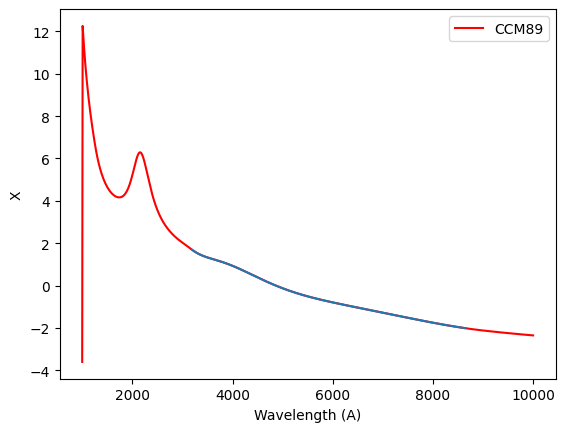

In [10]:
rc.plot(laws='CCM89')
plt.plot(rf_wl, np.log10(rc.getCorrHb(rf_wl))/ (0.4 * rc.E_BV))

In [11]:
# correcting a galaxy
# read E_BV
extinction = pd.read_table('/home/benjamin/Documents/analogs/dust/extinction.tbl',
                         comment='#', delim_whitespace=True)
for key in extinction.keys():
    extinction.rename(columns={key: key[1:]}, inplace=True)
extinction.drop([0, 1], axis=0, inplace=True)

In [12]:
igal = np.argmax(extinction['objname'] == gal_id) + 2 
E_BV = float(extinction['E_B_V_SandF'][igal])

In [13]:
rcJ0950 = pn.RedCorr(E_BV = E_BV, R_V = 3.1, law = 'CCM89')

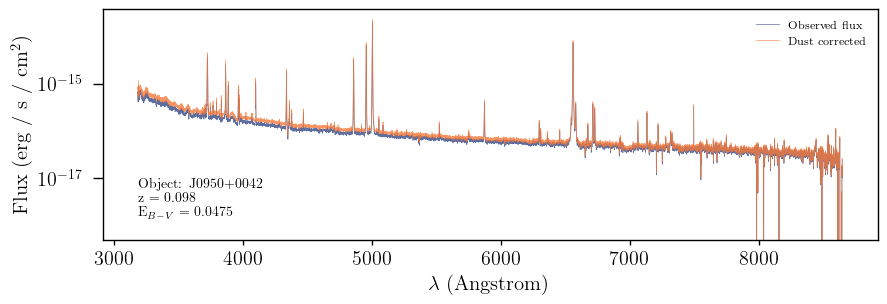

In [35]:
texPlot("on")
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 3)
ax.plot(rf_wl, flux, color=ccd[3],
        lw=0.5, label='Observed flux')
ax.plot(rf_wl, flux * rcJ0950.getCorr(rf_wl), color=cz[0],
        alpha=0.8, lw=0.5, label='Dust corrected')
ax.set_yscale('log')
ax.set_ylabel(r'Flux (erg / s / cm$^{2}$)', fontsize=15)
ax.set_xlabel(r'$\lambda$ (Angstrom)', fontsize=15)
ax.text(rf_wl[0], flux[0]/100, s='Object: '+source_dict['ext_name'][np.argmax(source_dict['name'] == gal_id)])
ax.text(rf_wl[0], flux[0]/200, s=r'z = '+str(z))
ax.text(rf_wl[0], flux[0]/400, s=r'E$_{B - V}$ = '+str(E_BV))
ax.legend(fontsize='small')

# Error in J2337

In [2]:
from astropy.io import fits

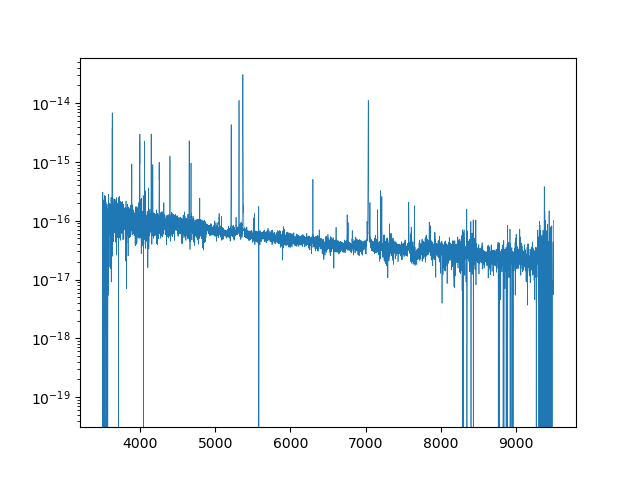

In [7]:
%matplotlib widget
J2337 = pd.read_csv('/home/benjamin/Documents/analogs/specs/pypeit_for_ppxf/J2337.csv')
plt.plot(J2337['wave'], J2337['flux'], lw=0.5)
plt.fill_between(J2337['wave'], J2337['flux'] - J2337['noise'], J2337['flux'] + J2337['noise'], alpha=0.2)
plt.yscale('log')

## STILL NOT FIXED

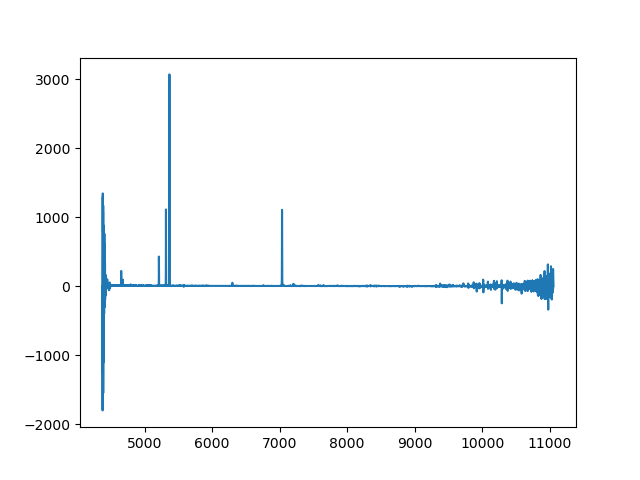

In [16]:
blue = fits.open('/home/benjamin/Documents/pypeit19b18/redux_j2337/blue2/magellan_mage_A/J2337_spec_tellcorr.fits')
red = fits.open('/home/benjamin/Documents/pypeit19b18/redux_j2337/red2/magellan_mage_A/J2337_spec_tellcorr.fits')
%matplotlib widget
#plt.plot(blue[1].data['wave'], blue[1].data['flux'])
plt.plot(red[1].data['wave'], red[1].data['flux'])

In [22]:
w_dl = red[1].data['wave'][-1] - red[1].data['wave'][-2]
b_dl = blue[1].data['wave'][1] - blue[1].data['wave'][0]
w_dl

0.06975844945009158

Using matplotlib backend: module://ipympl.backend_nbagg


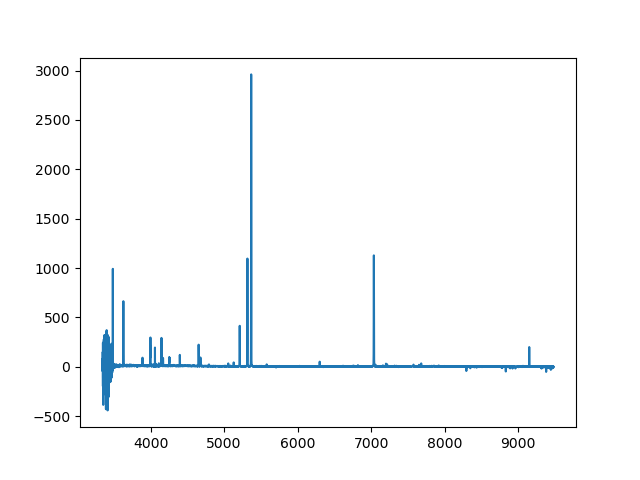

In [27]:
wave = np.arange(blue[1].data['wave'][0], blue[1].data['wave'][-1], b_dl)
from spectres import spectres

fl = spectres(wave, blue[1].data['wave'], blue[1].data['flux'])
%matplotlib
plt.plot(wave, fl)

# Getting windows for emission line masking

In [29]:
import glob
gals = glob.glob('/home/benjamin/Documents/analogs/specs/pypeit_for_ppxf/*')

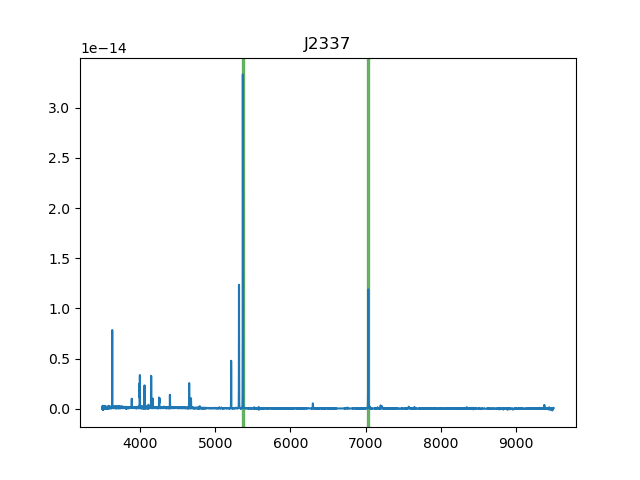

In [39]:
gal = gals[7]
galspec = pd.read_csv(gal)
%matplotlib widget
plt.plot(galspec['wave'], galspec['dcorr_flux'])
plt.title(gal[-9:-4])
plt.axvspan(5355, 5379, alpha=0.5, color='green')
plt.axvspan(7023, 7047, alpha=0.5, color='green')

# pPXF fits

In [2]:
from astropy.io import fits

fit = fits.open('/home/benjamin/Documents/analogs/PPXF2/fitting/pipeline_results/saved_fits/J2225_ppxfit.fits')

In [3]:
zFit = fit[0].header['zFit']

In [5]:
fit[6].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   16 / length of dimension 1                          
NAXIS2  =                 6539 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    2 / number of table fields                         
TTYPE1  = 'bestfit_popul'                                                       
TFORM1  = 'D       '                                                            
TTYPE2  = 'emission_popul'                                                      
TFORM2  = 'D       '                                                            
EXTNAME = 'PP_POPUL'        

In [28]:
zFit

0.06704000230791163

In [29]:
factor = (1 + 0.05337) / (1 + zFit)

In [30]:
1 + (1 - factor)

1.0128111432358158

In [31]:
wave_cat['Ha']

6562.79

In [32]:
(6877.5 / 6562.79) - 1

0.0479536904273945

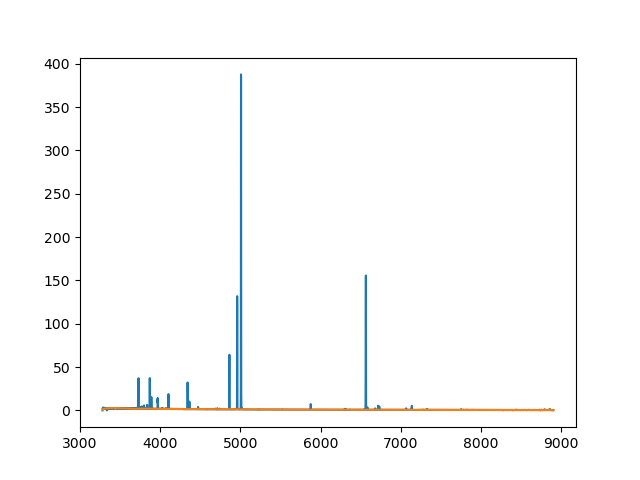

In [6]:
%matplotlib widget
plt.plot(fit[2].data['lam_kinem'], fit[2].data['galaxy_kinem'])
plt.plot(fit[2].data['lam_kinem'], fit[6].data['bestfit_popul'])
#plt.axvline(wave_cat['Ha'], lw=4, ls='--', color='black')
#plt.axvline(wave_cat['Ha']*(1 + 0.05337), lw=4, ls='--', color='black')
#plt.axvline(wave_cat['Ha']*(1 + zFit), lw=4, ls='--', color='green')

In [17]:
fit[0].header['zFit']

0.053

In [2]:
def mask_el_v2(lam_rf, z, window):
    """
    Gives a mask of the regions of the spectrum where the emission lines of the
    spectrum are located. It also accounts for remaining telluric bands that
    might appear in spectra.
    
    Params
    ------
        lam_rf : array
            Wavelengths in restframe
        window : int
            Window to mask bright lines
    
    Output
    ------
        mask : array
            Boolean array indicating the pixels where there is emission lines
            or telluric bands.
    """
    
    # mask telluric
    tell_mask = np.full_like(lam_rf, False)
    for wl_range in telluric:
        wl_up, wl_down = wl_range[1] / (1 + z), wl_range[0] / (1 + z)
        tell_mask += (lam_rf < wl_up) & (lam_rf > wl_down)

    # mask emission lines
    window = window # width of emission lines +3
    line_mask = np.full_like(lam_rf, False)
    for line in wave_cat.keys():
        if line in bright:
            wl_up = wave_cat[line] + window
            wl_down = wave_cat[line] - window
        else:
            wl_up = wave_cat[line] + 0.5 * window
            wl_down = wave_cat[line] - 0.5 * window
        line_mask += (lam_rf < wl_up) & (lam_rf > wl_down)

    # wrap up everything
    mask = ~(tell_mask + line_mask).astype(bool)
    
    return mask

In [18]:
specJ0023 = pd.read_csv('/home/benjamin/Documents/analogs/specs/pypeit_for_ppxf/J0023.csv')
wl, fl = specJ0023['wave'], specJ0023['dcorr_flux']

igal = np.argmax(source_dict['name'] == 'J0023')
window = source_dict['window'][igal]
z = 0.05337
rf_wl = wl / (1 + z)

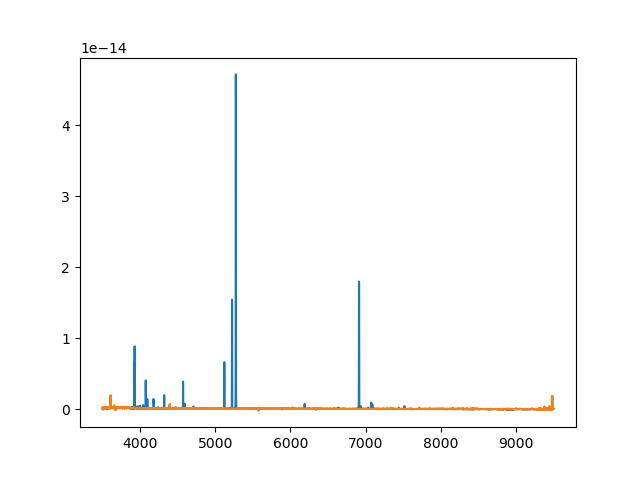

In [19]:
%matplotlib widget
plt.plot(wl, fl)
plt.plot(wl[mask_el_v2(rf_wl, z, window)], fl[mask_el_v2(rf_wl, z, window)])

In [ ]:
import ppxf.ppxf_util as util

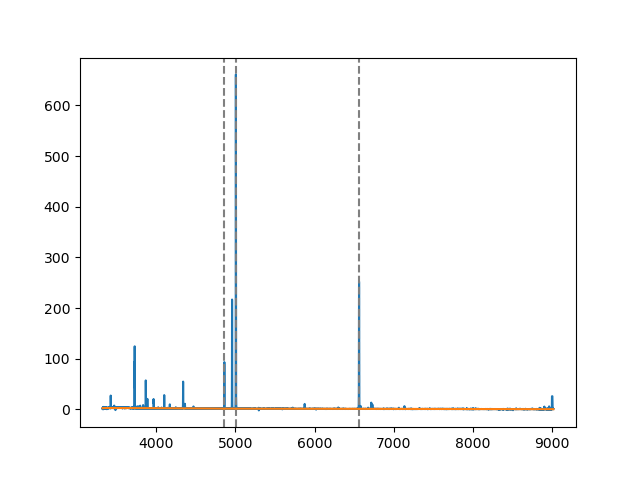

In [46]:
%matplotlib widget
plt.plot(fit[1].data['lam0']/(1 + 0.05337), fit[1].data['galaxy0']/np.nanmedian(fit[1].data['galaxy0']))
plt.axvline(wave_cat['Ha'], ls='--', c='gray')
plt.axvline(util.air_to_vac(wave_cat['Hb']), ls='--', c='gray')
plt.axvline(wave_cat['[OIII]5007'], ls='--', c='gray')
#plt.plot(fit[2].data['lam_kinem'], fit[2].data['galaxy_kinem'])
plt.plot(fit[1].data['lam0']/(1 + 0.05337), fit[2].data['bestfit_kinem'])

In [16]:
fit[0].data

# Precise redshift

In [102]:
i = 16
galname = source_dict['name'][i]
gal = pd.read_csv('/home/benjamin/Documents/analogs/specs/pypeit/'+galname+'.csv')
z_SDSS = source_dict['z_SDSS'][i]

Text(0.5, 1.0, 'J2337, z(SDSS) = 0.072')

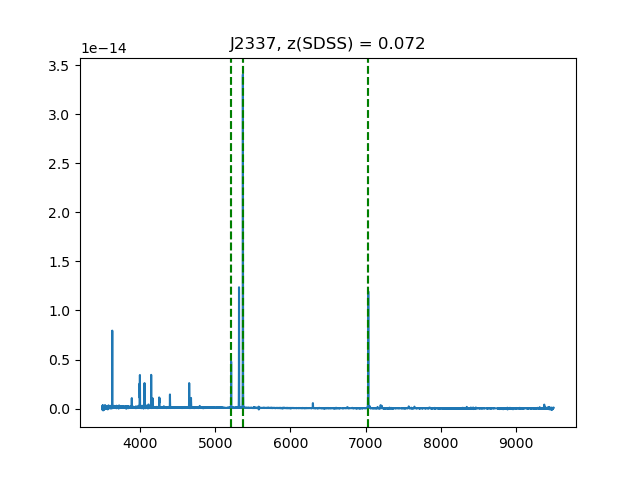

In [108]:
%matplotlib widget
plt.plot(gal['wave'], gal['dcorr_flux'])

z_BN = 0.07203

plt.axvline(wave_cat['Ha']*(1 + z_SDSS), color='gray', ls='--')
plt.axvline(wave_cat['Ha']*(1 + z_BN), color='green', ls='--')

plt.axvline(wave_cat['Hb']*(1 + z_SDSS), color='gray', ls='--')
plt.axvline(wave_cat['Hb']*(1 + z_BN), color='green', ls='--')

plt.axvline(wave_cat['[OIII]5007']*(1 + z_SDSS), color='gray', ls='--')
plt.axvline(wave_cat['[OIII]5007']*(1 + z_BN), color='green', ls='--')

plt.title(galname+', z(SDSS) = '+str(z_SDSS))

# Specs

In [45]:
from astropy.io import fits
import matplotlib.pyplot as plt

J0021_red = fits.open('/home/benjamin/Documents/pypeit23/redux_J2212/red/magellan_mage_A/J2212_red_tellcorr.fits')
J0021_blue = fits.open('/home/benjamin/Documents/pypeit23/redux_J2212_comp/red/magellan_mage_A/J2212_comp_red_tellcorr.fits')
#J0021_blue = fits.open('/home/benjamin/Documents/pypeit23/redux_J2212/blue/magellan_mage_A/J2212_blue_tellcorr.fits')

In [50]:
import spectres
flux_comp = spectres.spectres(J0021_red[1].data['wave'], J0021_blue[1].data['wave'], J0021_blue[1].data['flux'])


Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 



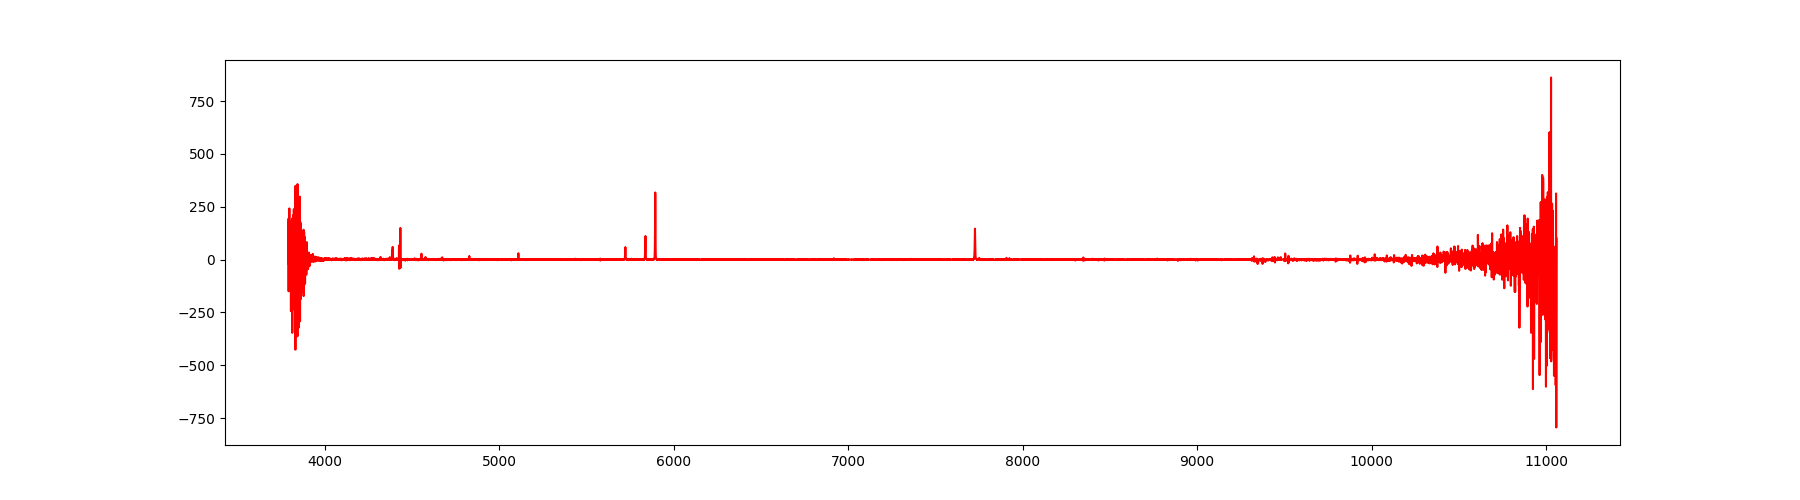

In [52]:
%matplotlib widget
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(18, 5)

ax.plot(J0021_red[1].data['wave'], J0021_red[1].data['flux'] - flux_comp, color='red')
#ax.plot(J0021_red[1].data['wave'], flux_comp, color='green')
#ax.fill_between(J0021_red[1].data['wave'], J0021_red[1].data['flux'] - (J0021_red[1].data['ivar']**-0.5),
#                                           J0021_red[1].data['flux'] + (J0021_red[1].data['ivar']**-0.5),
#               alpha=0.6, color='red')

#ax.plot(J0021_blue[1].data['wave'], J0021_blue[1].data['flux'], color='green')
#ax.fill_between(J0021_blue[1].data['wave'], J0021_blue[1].data['flux'] - (J0021_blue[1].data['ivar']**-0.5),
#                                           J0021_blue[1].data['flux'] + (J0021_blue[1].data['ivar']**-0.5),
#               alpha=0.6, color='green')

# Dou

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
from scipy.constants import c as lightspeed
from lmfit import minimize, Parameters
from astropy.io import fits
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian
from magE.plotutils import * 
from magE.constutils import *

In [4]:
J0021 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J0021.csv')
wave = J0021['wave'].to_numpy()
flux = J0021['flux'].to_numpy()
noise = J0021['noise'].to_numpy()

In [13]:
sdss_filters_lim = {'u': [3044.90, 3987.70],
                    'g': [3863.55, 5690.45],
                    'r': [5409.03, 7176.14],
                    'i': [6728.44, 8730.62],
                    'z': [8066.11, 13500.00]}

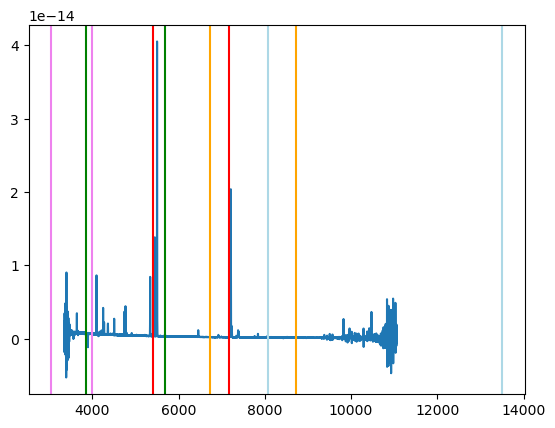

In [12]:
plt.plot(wave, flux)

# u filter
plt.axvline(3044.90, color='violet')
plt.axvline(3987.70, color='violet')

# g filter
plt.axvline(3863.55, color='green')
plt.axvline(5690.45, color='green')

# r filter
plt.axvline(5409.03, color='red')
plt.axvline(7176.14, color='red')

# i filter
plt.axvline(6728.44, color='orange')
plt.axvline(8730.62, color='orange')

# z filter
plt.axvline(8066.11, color='lightblue')
plt.axvline(13500.00, color='lightblue')

In [33]:
fluxes = []
for element in sdss_filters_lim:
    liminf, limsup = sdss_filters_lim[element]
    mask = (wave > liminf) & (wave < limsup)
    f_nu = flux * (wave**2) * 3.34 * 1e4 # in Jy
    fluxes.append(np.sum(f_nu[mask]))

In [40]:
fluxes

[0.7922971319306709,
 2.7106322159536704,
 1.9003702945000651,
 1.7713525462804434,
 1.9145187623936275]

In [36]:
m = -2.5 * np.log10(np.array(fluxes)/3631)

In [37]:
m

array([9.15284541, 7.81738913, 8.20297004, 8.27930311, 8.19491656])

In [2]:
m = 19.07511

In [30]:
np.sinh((m * np.log(10) / -2.5) - np.log(1.4e-10)) * 2 * 1e-10 * 3631 * 1000

0.060790920592937184

In [11]:
f_f0 = np.sinh(( -0.4 * m * np.log(10) - np.log(1.4e-10)) * 2 * 1e-10

In [14]:
S_mJy = f_f0 * 3631 

In [15]:
S_mJy

94.35885583292759

In [16]:
1 / 2.5

0.4

In [3]:
old = fits.open('/home/benjamin/Documents/sed_fitting/photo_sdss.fits')
new = fits.open('/home/benjamin/Documents/sed_fitting/photo_sdss2.fits')

In [8]:
old[1].data['modelMag_u']

array([19.075113, 19.764902, 19.452572, 17.56943 , 18.828041, 20.540556,
       19.58195 , 20.864399, 17.368649, 19.948963, 19.092346, 18.427492,
       20.35231 , 20.098045, 20.45511 , 20.704044, 20.029394, 17.20428 ],
      dtype=float32)

In [12]:
mask = new[1].data['cModelMag_u'] != 20.75238

Text(0, 0.5, 'composite Model u Magnitude')

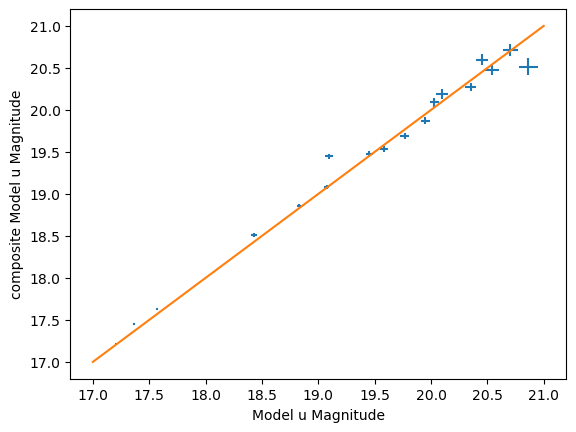

In [21]:
plt.errorbar(old[1].data['modelMag_u'], new[1].data['cModelMag_u'][mask],
             xerr = old[1].data['modelMagErr_u'],
             yerr = new[1].data['cModelMagErr_u'][mask], ls='')
plt.plot(np.arange(17, 22, 1), np.arange(17, 22, 1))
plt.xlabel('Model u Magnitude')
plt.ylabel('composite Model u Magnitude')

# J2212 spec

In [13]:
J2212 = pd.read_csv(magePath+'/specs/final_spec/J2212.csv')

In [77]:
igal = np.argmax(np.array(galnames) == 'J2212')
igal_comp = np.argmax(np.array(galnames) == 'J2212_comp')

In [14]:
J2212_comp = pd.read_csv(magePath+'/specs/final_spec/J2212_comp.csv')

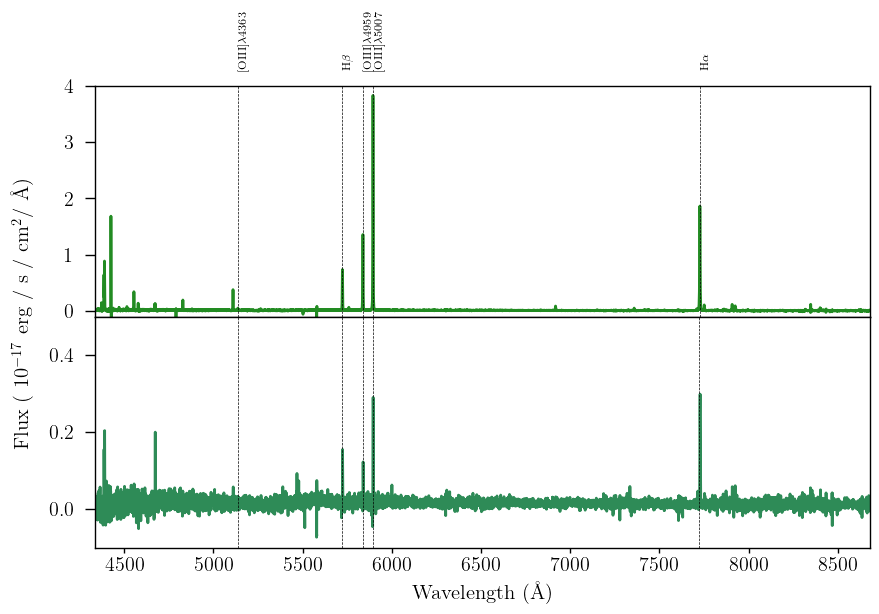

In [124]:
texPlot('on')
fig, axes = plt.subplots(2, 1, sharex=True)
fig.set_size_inches((10, 6))
fig.subplots_adjust(hspace=0.)
fig.text(0.04, 0.5, r'Flux ( 10$^{-17}$ erg / s / cm$^{2} /$ \AA)',
         fontsize=15, va="center", rotation="vertical")

axes[0].plot(J2212['wave'], J2212['flux']*1e15, lw=2, color='forestgreen')
axes[1].plot(J2212_comp['wave'], J2212_comp['flux']*1e15, lw=2, color='seagreen')

axes[0].text(wave_cat['Ha'] * (1 + z_BN[igal]), 4.3, s=r'H$\alpha$', rotation=90, fontsize='small')
axes[0].text(wave_cat['[OIII]5007'] * (1 + z_BN[igal]), 4.3, s=r'[OIII]$\lambda$5007', rotation=90, fontsize='small')
axes[0].text(wave_cat['[OIII]4959'] * (1 + z_BN[igal]), 4.3, s=r'[OIII]$\lambda$4959', rotation=90, fontsize='small')
axes[0].text(wave_cat['Hb'] * (1 + z_BN[igal]), 4.3, s=r'H$\beta$', rotation=90, fontsize='small')
axes[0].text(wave_cat['[OIII]4363'] * (1 + z_BN[igal]), 4.3, s=r'[OIII]$\lambda$4363', rotation=90, fontsize='small')

axes[0].axvline(wave_cat['Ha'] * (1 + z_BN[igal]), ls='--', color='black', lw=0.5)
axes[1].axvline(wave_cat['Ha'] * (1 + z_BN[igal_comp]), ls='--', color='black', lw=0.5)

axes[0].axvline(wave_cat['[OIII]5007'] * (1 + z_BN[igal]), ls='--', color='black', lw=0.5)
axes[1].axvline(wave_cat['[OIII]5007'] * (1 + z_BN[igal_comp]), ls='--', color='black', lw=0.5)

axes[0].axvline(wave_cat['[OIII]4959'] * (1 + z_BN[igal]), ls='--', color='black', lw=0.5)
axes[1].axvline(wave_cat['[OIII]4959'] * (1 + z_BN[igal_comp]), ls='--', color='black', lw=0.5)

axes[0].axvline(wave_cat['Hb'] * (1 + z_BN[igal]), ls='--', color='black', lw=0.5)
axes[1].axvline(wave_cat['Hb'] * (1 + z_BN[igal_comp]), ls='--', color='black', lw=0.5)

axes[0].axvline(wave_cat['[OIII]4363'] * (1 + z_BN[igal]), ls='--', color='black', lw=0.5)
axes[1].axvline(wave_cat['[OIII]4363'] * (1 + z_BN[igal_comp]), ls='--', color='black', lw=0.5)

axes[0].set_xlim(wave_cat['[OII]3726'] * (1 + z_BN[igal]) - 50, wave_cat['[OII]7330'] * (1 + z_BN[igal]) + 50)
axes[0].set_ylim(-0.1, 4)
axes[1].set_ylim(-0.1, 0.5)
axes[1].set_xlabel('Wavelength (\AA)', fontsize=15)
#fig.savefig('J2212_case.jpg', bbox_inches='tight')

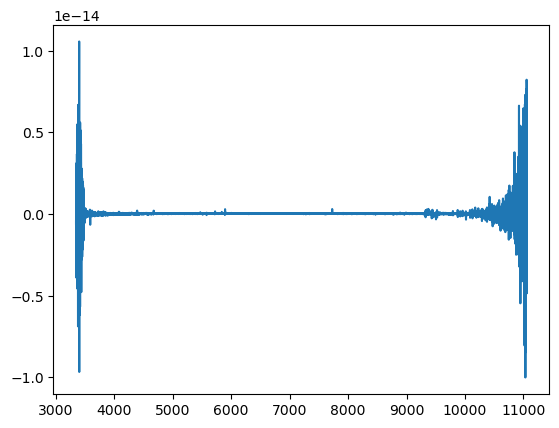

In [16]:
plt.plot(J2212_comp['wave'], J2212_comp['flux'])